## 0.データのフィルタリング・クリーニング 関数

### データ読み込みと結合

In [1]:
#csvファイルではなくtxtファイルを読み込む
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


path_1 = Path('../data/raw/trajectories-0400-0415.txt')
path_2 = Path('../data/raw/trajectories-0500-0515.txt')
path_3 = Path('../data/raw/trajectories-0515-0530.txt')

columns = [
    'Vehicle_ID', 'Frame_ID', 'Total_Frames', 'Global_Time', 'Local_X', 'Local_Y',
    'Global_X', 'Global_Y', 'v_Length', 'v_Width', 'v_Class', 'v_Vel', 'v_Acc',
    'Lane_ID', 'Preceding', 'Following', 'Space_Headway', 'Time_Headway'
]

df_1 = pd.read_csv(path_1, sep=r'\s+', header=None, names=columns)
df_2 = pd.read_csv(path_2, sep=r'\s+', header=None, names=columns)
df_3 = pd.read_csv(path_3, sep=r'\s+', header=None, names=columns)

# 時間帯の識別列を追加 (id の重複があるため)
df_1['time_period'] = 1  # 4:00-4:15
df_2['time_period'] = 2  # 5:00-5:15
df_3['time_period'] = 3  # 5:15-5:30

# 結合
df = pd.concat([df_1, df_2, df_3], ignore_index=True)

# データの確認
print(df.shape)
df.head()

(4566387, 19)


,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,v_Class,v_Vel,v_Acc,Lane_ID,Preceding,Following,Space_Headway,Time_Headway,time_period
0,1,12,884,1113433136100,16.884,48.213,6042842.116,2133117.662,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0,1
1,1,13,884,1113433136200,16.938,49.463,6042842.012,2133118.909,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0,1
2,1,14,884,1113433136300,16.991,50.712,6042841.908,2133120.155,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0,1
3,1,15,884,1113433136400,17.045,51.963,6042841.805,2133121.402,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0,1
4,1,16,884,1113433136500,17.098,53.213,6042841.701,2133122.649,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0,1


In [2]:
# 列名の確認
print(df.columns.tolist())

# データ型の確認
print(df.dtypes)

#欠損値　
print("\n欠損値:")
df.isnull().sum()

# 基本統計量
df.describe()

#v,accはfeet表示

['Vehicle_ID', 'Frame_ID', 'Total_Frames', 'Global_Time', 'Local_X', 'Local_Y', 'Global_X', 'Global_Y', 'v_Length', 'v_Width', 'v_Class', 'v_Vel', 'v_Acc', 'Lane_ID', 'Preceding', 'Following', 'Space_Headway', 'Time_Headway', 'time_period']
Vehicle_ID         int64
Frame_ID           int64
Total_Frames       int64
Global_Time        int64
Local_X          float64
Local_Y          float64
Global_X         float64
Global_Y         float64
v_Length         float64
v_Width          float64
v_Class            int64
v_Vel            float64
v_Acc            float64
Lane_ID            int64
Preceding          int64
Following          int64
Space_Headway    float64
Time_Headway     float64
time_period        int64
dtype: object

欠損値:


,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,v_Class,v_Vel,v_Acc,Lane_ID,Preceding,Following,Space_Headway,Time_Headway,time_period
count,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06
mean,1.588199e+03,5.471980e+03,1.015003e+03,1.113437e+12,3.984736e+01,8.430695e+02,6.042761e+06,2.133909e+06,1.611579e+01,6.852992e+00,2.032801e+00,1.934866e+01,6.237478e-03,3.832722e+00,1.513829e+03,1.523074e+03,5.435219e+01,4.221553e+02,2.107550e+00
std,8.078982e+02,2.661235e+03,4.787489e+02,1.881963e+06,2.107819e+01,4.487661e+02,6.778314e+01,4.447039e+02,7.311574e+00,8.721375e-01,2.005007e-01,1.317379e+01,4.753486e+00,1.680516e+00,8.518476e+02,8.533007e+02,3.725520e+01,1.999911e+03,8.056143e-01
min,1.000000e+00,4.000000e+00,2.030000e+02,1.113433e+12,0.000000e+00,0.000000e+00,6.042587e+06,2.133040e+06,4.900000e+00,2.700000e+00,1.000000e+00,0.000000e+00,-1.120000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,9.540000e+02,3.237000e+03,6.750000e+02,1.113434e+12,1.895600e+01,4.651840e+02,6.042705e+06,2.133535e+06,1.380000e+01,6.300000e+00,2.000000e+00,9.780000e+00,-6.000000e-01,2.000000e+00,8.440000e+02,8.530000e+02,3.300000e+01,2.070000e+00,1.000000e+00
50%,1.642000e+03,5.712000e+03,8.900000e+02,1.113437e+12,4.113200e+01,8.188110e+02,6.042766e+06,2.133885e+06,1.480000e+01,6.900000e+00,2.000000e+00,1.792000e+01,0.000000e+00,4.000000e+00,1.584000e+03,1.592000e+03,4.638000e+01,2.980000e+00,2.000000e+00
75%,2.191000e+03,7.704000e+03,1.358000e+03,1.113438e+12,5.476500e+01,1.228128e+03,6.042818e+06,2.134291e+06,1.590000e+01,7.400000e+00,2.000000e+00,2.649000e+01,6.300000e-01,5.000000e+00,2.156000e+03,2.166000e+03,6.660000e+01,4.620000e+00,3.000000e+00
max,3.366000e+03,1.169100e+04,2.434000e+03,1.113439e+12,9.699600e+01,1.790771e+03,6.042911e+06,2.134845e+06,7.770000e+01,8.500000e+00,3.000000e+00,9.530000e+01,1.120000e+01,7.000000e+00,3.366000e+03,3.366000e+03,1.321550e+03,1.173390e+04,3.000000e+00


In [3]:
# 車種の分布確認
print("車種の分布:")
print(df['v_Class'].value_counts())

# 車線の分布確認
print("\n車線の分布:")
print(df['Lane_ID'].value_counts().sort_index())

車種の分布:
v_Class
2    4377903
3     169132
1      19352
Name: count, dtype: int64

車線の分布:
Lane_ID
1    404588
2    830690
3    719832
4    880189
5    785454
6    791237
7    154397
Name: count, dtype: int64


#### データのノイズ除去

In [4]:
def remove_flicker_noise(df, col='Preceding', threshold=5):
    """
    先行車ID(Preceding)の短時間フリッカリングを除去する。
    「長いA → threshold以下のB → 長いA」の形（前後の値が完全一致する
    短いブロック）のみを対象とし、直前の値(A)で補間する。
    A→B→C→...→Aのような連鎖的な変化は対象外（そのまま残す）。
    """
    df = df.sort_values(['time_period', 'Vehicle_ID', 'Global_Time']).copy()

    # 車両・時間帯・値のいずれかが変わったら新しいブロックの開始
    is_new_block = (
        (df['Vehicle_ID'] != df['Vehicle_ID'].shift()) |
        (df['time_period'] != df['time_period'].shift()) |
        (df[col] != df[col].shift())
    )
    df['_block_id'] = is_new_block.cumsum()

    blocks = df.groupby('_block_id').agg(
        Vehicle_ID=('Vehicle_ID', 'first'),
        time_period=('time_period', 'first'),
        value=(col, 'first'),
        frame_count=(col, 'size'),
    )

    # 前後ブロックは同一車両・時間帯の中でのみ参照する
    blocks['prev_value'] = blocks.groupby(['Vehicle_ID', 'time_period'])['value'].shift(1)
    blocks['next_value'] = blocks.groupby(['Vehicle_ID', 'time_period'])['value'].shift(-1)

    # フリッカリング判定：短いブロックの前後の値が完全一致する場合のみ
    is_flicker = (
        (blocks['frame_count'] <= threshold)
        & (blocks['prev_value'] == blocks['next_value'])
        & blocks['prev_value'].notna()
    )

    replacement = blocks['prev_value'].where(is_flicker)
    df[col] = df['_block_id'].map(replacement).fillna(df[col])
    df = df.drop(columns='_block_id')

    print("フリッカリング除去完了")
    print(f"補正されたブロック数: {is_flicker.sum():,}")
    print(f"行数: {len(df):,}")

    return df

In [5]:
test_data = {
    'Vehicle_ID':  [1]*8 + [2]*10,
    'time_period': [1]*8 + [1]*10,
    'Global_Time': list(range(100, 900, 100)) + list(range(100, 1100, 100)),
    'Preceding':   [5,5,5, 0,0, 5,5,5] + [7,7,7, 9,9, 3,3, 7,7,7],
}
df_test = pd.DataFrame(test_data)
result = remove_flicker_noise(df_test, threshold=5)
print(result[['Vehicle_ID', 'Global_Time', 'Preceding']])

フリッカリング除去完了
補正されたブロック数: 1
行数: 18
    Vehicle_ID  Global_Time  Preceding
0            1          100        5.0
1            1          200        5.0
2            1          300        5.0
3            1          400        5.0
4            1          500        5.0
5            1          600        5.0
6            1          700        5.0
7            1          800        5.0
8            2          100        7.0
9            2          200        7.0
10           2          300        7.0
11           2          400        9.0
12           2          500        9.0
13           2          600        3.0
14           2          700        3.0
15           2          800        7.0
16           2          900        7.0
17           2         1000        7.0


In [24]:
df_remve_noise = remove_flicker_noise(df, col='Preceding', threshold=5)

フリッカリング除去完了
補正されたブロック数: 435
行数: 4,566,387


### 1.すべての追従ペアにペアIDと追従モード識別番号を付与　(df_with_pairsを作成)

In [103]:
#追従ペアIDを付与する関数
def give_pair_id(df):
    """
    追従ペアIDを付与する関数
    """
    df = df.sort_values(['time_period', 'Vehicle_ID', 'Global_Time']).copy()

    # 追従が途切れるタイミングを検出（直前の行と比較して変化したら旗を立てる）
    vehicle_changed      = df['Vehicle_ID']  != df['Vehicle_ID'].shift()
    time_period_changed  = df['time_period'] != df['time_period'].shift()
    lane_changed         = df['Lane_ID']     != df['Lane_ID'].shift()
    preceding_changed    = df['Preceding']   != df['Preceding'].shift()

    # どれか1つでもTrueなら追従の切れ目
    break_point = vehicle_changed | time_period_changed | lane_changed | preceding_changed

    # ペアIDを付与
    df['pair_id'] = break_point.cumsum()

    # Preceding=0の行はpair_idをNaNにする（追従関係がないため）
    preceding_zero = df['Preceding'] == 0
    df.loc[preceding_zero, 'pair_id'] = None

    return df


#追従ペアIDを付与する関数
def give_mode_id(df, original_df):
    """
    追従ペアにモードIDを付与する関数
    
    モードID（ego_class, leader_class）：
    (c-c)=1, (c-t)=2, (t-c)=3
    (t-t)=4, (others)=5,
    """
    mode_map = {
        (2,2): 1, (2,3): 2, (3,2): 3,
        (3,3): 4, (2,1): 5, (3,1): 5,
        (1,1): 5, (1,2): 5, (1,3): 5
    }
    
    # 元データから前方車両の車種を取得
    leader_class = original_df[['Vehicle_ID', 'v_Class','time_period']].drop_duplicates()
    leader_class = leader_class.rename(columns={'Vehicle_ID': 'Preceding', 'v_Class': 'leader_class'})
    
    # 結合
    df = df.merge(leader_class, on=['Preceding', 'time_period'], how='left')
    df['ego_class'] = df['v_Class']
    
    # モードIDを付与（NaNの場合はNoneを返す）
    def get_mode_id(row):
        if pd.isna(row['leader_class']):
            return None
        return mode_map.get((int(row['ego_class']), int(row['leader_class'])))
    
    df['mode_id'] = df.apply(get_mode_id, axis=1)
    
    # 確認
    pairs_count = df.dropna(subset=['pair_id']).groupby(['pair_id', 'mode_id']).size().reset_index()
    summary = pairs_count.groupby('mode_id').size()
    print("モードID別ペア数:")
    print(summary)
    
    return df

In [105]:
# 実行 ペアID付与
df_with_pairs = give_pair_id(df)

# 確認
print(f"総行数: {len(df_with_pairs):,}")
print(f"追従ペア数: {df_with_pairs['pair_id'].nunique():,}")

# 実行　ペアモード付与
df_with_mode = give_mode_id(df_with_pairs, df)

print(f"\n総行数: {len(df_with_mode):,}")
print(f"追従ペア数: {df_with_mode['pair_id'].nunique():,}")

総行数: 4,566,387
追従ペア数: 14,800
モードID別ペア数:
mode_id
1.0    13136
2.0      471
3.0      593
4.0       46
5.0      554
dtype: int64

総行数: 4,566,387
追従ペア数: 14,800


##### test

In [ ]:
def make_case(rows, vehicle_id=1, time_period=1, start_time=1000):
    """
    rows: [(Lane_ID, Preceding), ...] のリスト。1行=1フレーム(0.1秒間隔)
    """
    n = len(rows)
    return pd.DataFrame({
        'Vehicle_ID':  [vehicle_id]*n,
        'time_period': [time_period]*n,
        'Global_Time': [start_time + i*100 for i in range(n)],
        'Lane_ID':     [r[0] for r in rows],
        'Preceding':   [r[1] for r in rows],
    })

def check_pairs(df, name, expected_lengths, apply_flicker=False, flicker_col='Preceding', threshold=5):
    if apply_flicker:
        df = remove_flicker_noise(df, col=flicker_col, threshold=threshold)
    result = give_pair_id(df)
    valid = result.dropna(subset=['pair_id'])
    actual_lengths = valid.groupby('pair_id').size().tolist()

    status = "OK " if actual_lengths == expected_lengths else "NG "
    print(f"[{status}] {name}")
    print(f"      期待: {expected_lengths} / 実際: {actual_lengths}")
    return result


# ============================================================
# ① 本物の交通イベント（正しく途切れるべきもの）
# ============================================================

# --- 1-1. ベースライン: 何も起きない連続追従 ---
df1 = make_case([(2, 5)] * 30)
check_pairs(df1, "1-1 通常の連続追従", expected_lengths=[30])

# --- 1-2. 自車の車線変更（Precedingは偶然同じ値のまま） ---
df2 = make_case([(2, 5)] * 15 + [(3, 5)] * 15)
check_pairs(df2, "1-2 自車の車線変更", expected_lengths=[15, 15])

# --- 1-3. 先行車の車線変更（自車のLaneは変わらない） ---
df3 = make_case([(2, 5)] * 15 + [(2, 8)] * 15)
check_pairs(df3, "1-3 先行車の交代", expected_lengths=[15, 15])

# --- 1-4. 先行車が区間退出（Preceding=0が長く続く） ---
df4 = make_case([(2, 5)] * 15 + [(2, 0)] * 10)
check_pairs(df4, "1-4 先行車が区間退出", expected_lengths=[15])


# ============================================================
# ② データ由来のノイズ（本来は途切れさせたくないもの）
# ============================================================

# --- 2-1. Precedingが一瞬0（3フレーム、閾値5以下） ---
df5 = make_case([(2, 5)] * 10 + [(2, 0)] * 3 + [(2, 5)] * 10)
check_pairs(df5, "2-1a 生データ(補正前): 一瞬0", expected_lengths=[10, 10])
check_pairs(df5, "2-1b flicker補正後: 一瞬0",   expected_lengths=[23], apply_flicker=True)

# --- 2-2. Precedingが一瞬別ID（3フレーム、閾値5以下） ---
df6 = make_case([(2, 5)] * 10 + [(2, 9)] * 3 + [(2, 5)] * 10)
check_pairs(df6, "2-2a 生データ(補正前): 一瞬別ID", expected_lengths=[10, 3, 10])
check_pairs(df6, "2-2b flicker補正後: 一瞬別ID",   expected_lengths=[23], apply_flicker=True)

# --- 2-3. Lane_IDの一瞬のブレ（3フレーム、閾値5以下） ---
df7 = make_case([(2, 5)] * 10 + [(3, 5)] * 3 + [(2, 5)] * 10)
check_pairs(df7, "2-3a 生データ(補正前): Laneブレ", expected_lengths=[10, 3, 10])
check_pairs(df7, "2-3b flicker補正後(Lane_ID対象): Laneブレ",
            expected_lengths=[23], apply_flicker=True, flicker_col='Lane_ID')

# --- 2-4. フレーム欠損（値は同じだが時間が飛んでいる） ---
df8 = make_case([(2, 5)] * 10)
df8_gap = make_case([(2, 5)] * 10, start_time=df8['Global_Time'].max() + 600)  # 0.6秒分の欠損
df8_full = pd.concat([df8, df8_gap], ignore_index=True)
result8 = check_pairs(df8_full, "2-4 フレーム欠損（現状の挙動確認）", expected_lengths=[20])
valid8 = result8.dropna(subset=['pair_id'])
duration8 = (valid8['Global_Time'].max() - valid8['Global_Time'].min()) / 1000
print(f"      → 行数20なのに区間長={duration8}秒（本来2.0秒のはずが欠損分だけ長く出る）")


# ============================================================
# ③ 境界のクロスコンタミネーション確認（バグ検出用）
# ============================================================

# --- 3-1. 異なる車両で値が同じでも混ざらないか ---
v1 = make_case([(2, 5)] * 10, vehicle_id=1)
v2 = make_case([(2, 5)] * 10, vehicle_id=2, start_time=v1['Global_Time'].max() + 100)
df9 = pd.concat([v1, v2], ignore_index=True)
check_pairs(df9, "3-1 異なる車両の混在", expected_lengths=[10, 10])

# --- 3-2. 同じVehicle_IDでも異なるtime_periodなら混ざらないか ---
t1 = make_case([(2, 5)] * 10, vehicle_id=1, time_period=1)
t2 = make_case([(2, 5)] * 10, vehicle_id=1, time_period=2)
df10 = pd.concat([t1, t2], ignore_index=True)
check_pairs(df10, "3-2 同一Vehicle_ID・異time_period", expected_lengths=[10, 10])

[OK ] 1-1 通常の連続追従
      期待: [30] / 実際: [30]
[OK ] 1-2 自車の車線変更
      期待: [15, 15] / 実際: [15, 15]
[OK ] 1-3 先行車の交代
      期待: [15, 15] / 実際: [15, 15]
[OK ] 1-4 先行車が区間退出
      期待: [15] / 実際: [15]
[OK ] 2-1a 生データ(補正前): 一瞬0
      期待: [10, 10] / 実際: [10, 10]
フリッカリング除去完了
補正されたブロック数: 1
行数: 23
[OK ] 2-1b flicker補正後: 一瞬0
      期待: [23] / 実際: [23]
[OK ] 2-2a 生データ(補正前): 一瞬別ID
      期待: [10, 3, 10] / 実際: [10, 3, 10]
フリッカリング除去完了
補正されたブロック数: 1
行数: 23
[OK ] 2-2b flicker補正後: 一瞬別ID
      期待: [23] / 実際: [23]
[OK ] 2-3a 生データ(補正前): Laneブレ
      期待: [10, 3, 10] / 実際: [10, 3, 10]
フリッカリング除去完了
補正されたブロック数: 1
行数: 23
[OK ] 2-3b flicker補正後(Lane_ID対象): Laneブレ
      期待: [23] / 実際: [23]
[OK ] 2-4 フレーム欠損（現状の挙動確認）
      期待: [20] / 実際: [20]
      → 行数20なのに区間長=2.4秒（本来2.0秒のはずが欠損分だけ長く出る）
[OK ] 3-1 異なる車両の混在
      期待: [10, 10] / 実際: [10, 10]
[OK ] 3-2 同一Vehicle_ID・異time_period
      期待: [10, 10] / 実際: [10, 10]


,Vehicle_ID,time_period,Global_Time,Lane_ID,Preceding,pair_id
0,1,1,1000,2,5,1.0
1,1,1,1100,2,5,1.0
2,1,1,1200,2,5,1.0
3,1,1,1300,2,5,1.0
4,1,1,1400,2,5,1.0
5,1,1,1500,2,5,1.0
6,1,1,1600,2,5,1.0
7,1,1,1700,2,5,1.0
8,1,1,1800,2,5,1.0
9,1,1,1900,2,5,1.0


In [112]:
def make_mode_case(follower_rows, roster_rows):
    """
    follower_rows: [(Preceding, time_period, ego_class, pair_id), ...]  ← give_pair_id適用後のdfに相当
    roster_rows:   [(Vehicle_ID, v_Class, time_period), ...]            ← original_dfに相当（全車両名簿）
    """
    df = pd.DataFrame(follower_rows, columns=['Preceding', 'time_period', 'v_Class', 'pair_id'])
    original_df = pd.DataFrame(roster_rows, columns=['Vehicle_ID', 'v_Class', 'time_period'])
    return df, original_df

def check_mode_id(df, original_df, name, expected_mode_ids, check_row_count=True):
    result = give_mode_id(df.copy(), original_df)
    actual = [None if pd.isna(x) else int(x) for x in result['mode_id'].tolist()]

    len_ok = (len(result) == len(df)) if check_row_count else True
    status = "OK " if (actual == expected_mode_ids and len_ok) else "NG "
    print(f"[{status}] {name}")
    print(f"      期待: {expected_mode_ids} / 実際: {actual}")
    if not len_ok:
        print(f"      ⚠ 行数が変化: 入力{len(df)}行 → 出力{len(result)}行（結合で行が増減している）")
    return result


# ============================================================
# A. mode_mapの9通りの組み合わせを網羅
# ============================================================
# 名簿: Vehicle_ID=1(car), 2(truck), 3(motorcycle)  すべてtime_period=1
roster_a = [(1, 2, 1), (2, 3, 1), (3, 1, 1)]

follower_a = [
    (1, 1, 2, 101),  # leader=car,   ego=car        -> (2,2)=1
    (2, 1, 2, 102),  # leader=truck, ego=car        -> (2,3)=2
    (1, 1, 3, 103),  # leader=car,   ego=truck       -> (3,2)=3
    (2, 1, 3, 104),  # leader=truck, ego=truck       -> (3,3)=4
    (3, 1, 2, 105),  # leader=motorcycle, ego=car    -> (2,1)=5
    (3, 1, 3, 106),  # leader=motorcycle, ego=truck  -> (3,1)=5
    (3, 1, 1, 107),  # leader=motorcycle, ego=motorcycle -> (1,1)=5
    (1, 1, 1, 108),  # leader=car,   ego=motorcycle  -> (1,2)=5
    (2, 1, 1, 109),  # leader=truck, ego=motorcycle  -> (1,3)=5
]
df_a, orig_a = pd.DataFrame(follower_a, columns=['Preceding','time_period','v_Class','pair_id']), pd.DataFrame(roster_a, columns=['Vehicle_ID','v_Class','time_period'])
check_mode_id(df_a, orig_a, "A. 9通りの組み合わせ", expected_mode_ids=[1,2,3,4,5,5,5,5,5])


# ============================================================
# B. leaderが名簿に見つからない（Preceding=0 や 存在しないID）
# ============================================================
roster_b = [(1, 2, 1)]
follower_b = [
    (0,   1, 2, 201),  # Preceding=0（追従なし）
    (999, 1, 2, 202),  # 存在しない車両ID
]
df_b, orig_b = pd.DataFrame(follower_b, columns=['Preceding','time_period','v_Class','pair_id']), pd.DataFrame(roster_b, columns=['Vehicle_ID','v_Class','time_period'])
check_mode_id(df_b, orig_b, "B. leaderが見つからない", expected_mode_ids=[None, None])


# ============================================================
# C. 同じVehicle_IDでもtime_periodが違えば別車両として扱われるか
# ============================================================
roster_c = [
    (5, 2, 1),  # time_period=1のID=5は乗用車
    (5, 3, 2),  # time_period=2のID=5はトラック（別車両）
]
follower_c = [
    (5, 1, 2, 301),  # time_period=1でPreceding=5を追従 -> leaderはcar  -> (2,2)=1
    (5, 2, 2, 302),  # time_period=2でPreceding=5を追従 -> leaderはtruck -> (2,3)=2
]
df_c, orig_c = pd.DataFrame(follower_c, columns=['Preceding','time_period','v_Class','pair_id']), pd.DataFrame(roster_c, columns=['Vehicle_ID','v_Class','time_period'])
check_mode_id(df_c, orig_c, "C. time_periodをまたいだID重複", expected_mode_ids=[1, 2])


# ============================================================
# D. 名簿側で同一(Vehicle_ID, time_period)にv_Classの矛盾がある場合
#    （drop_duplicates()で吸収しきれず、mergeで行が増殖しないか）
# ============================================================
roster_d = [
    (7, 2, 1),  # ID=7がフレームAでは乗用車(2)
    (7, 3, 1),  # 同じID=7がフレームBではトラック(3)として記録されている(矛盾データ)
]
follower_d = [
    (7, 1, 2, 401),  # Preceding=7を1行だけ追従
]
df_d, orig_d = pd.DataFrame(follower_d, columns=['Preceding','time_period','v_Class','pair_id']), pd.DataFrame(roster_d, columns=['Vehicle_ID','v_Class','time_period'])
result_d = give_mode_id(df_d.copy(), orig_d)
print(f"[{'OK ' if len(result_d)==1 else 'NG '}] D. 名簿側のv_Class矛盾")
print(f"      入力1行 → 出力{len(result_d)}行  mode_id={result_d['mode_id'].tolist()}")


# ============================================================
# E. ego_classがv_Classをそのままコピーしているか
# ============================================================
roster_e = [(1, 2, 1)]
follower_e = [(1, 1, 3, 601)]  # ego_class=3(トラック)
df_e, orig_e = pd.DataFrame(follower_e, columns=['Preceding','time_period','v_Class','pair_id']), pd.DataFrame(roster_e, columns=['Vehicle_ID','v_Class','time_period'])
result_e = give_mode_id(df_e.copy(), orig_e)
print(f"[{'OK ' if result_e['ego_class'].iloc[0]==3 else 'NG '}] E. ego_classのコピー確認")
print(f"      期待: 3 / 実際: {result_e['ego_class'].iloc[0]}")


# ============================================================
# F. 想定外のクラス値(1,2,3以外)が来てもクラッシュしないか
# ============================================================
roster_f = [(1, 2, 1), (2, 9, 1)]  # ID=2は異常なクラス値9
follower_f = [
    (1, 1, 9, 701),  # egoが異常値9、leaderは正常(car)
    (2, 1, 2, 702),  # egoは正常(car)、leaderが異常値9
]
df_f, orig_f = pd.DataFrame(follower_f, columns=['Preceding','time_period','v_Class','pair_id']), pd.DataFrame(roster_f, columns=['Vehicle_ID','v_Class','time_period'])
check_mode_id(df_f, orig_f, "F. 未知のクラス値", expected_mode_ids=[None, None])

モードID別ペア数:
mode_id
1    1
2    1
3    1
4    1
5    5
dtype: int64
[OK ] A. 9通りの組み合わせ
      期待: [1, 2, 3, 4, 5, 5, 5, 5, 5] / 実際: [1, 2, 3, 4, 5, 5, 5, 5, 5]
モードID別ペア数:
Series([], dtype: int64)
[OK ] B. leaderが見つからない
      期待: [None, None] / 実際: [None, None]
モードID別ペア数:
mode_id
1    1
2    1
dtype: int64
[OK ] C. time_periodをまたいだID重複
      期待: [1, 2] / 実際: [1, 2]
モードID別ペア数:
mode_id
1    1
2    1
dtype: int64
[NG ] D. 名簿側のv_Class矛盾
      入力1行 → 出力2行  mode_id=[1, 2]
モードID別ペア数:
mode_id
3    1
dtype: int64
[OK ] E. ego_classのコピー確認
      期待: 3 / 実際: 3
モードID別ペア数:
Series([], dtype: int64)
[OK ] F. 未知のクラス値
      期待: [None, None] / 実際: [None, None]


,Preceding,time_period,v_Class,pair_id,leader_class,ego_class,mode_id
0,1,1,9,701,2,9,None
1,2,1,2,702,9,2,None



ペアIDの分布:


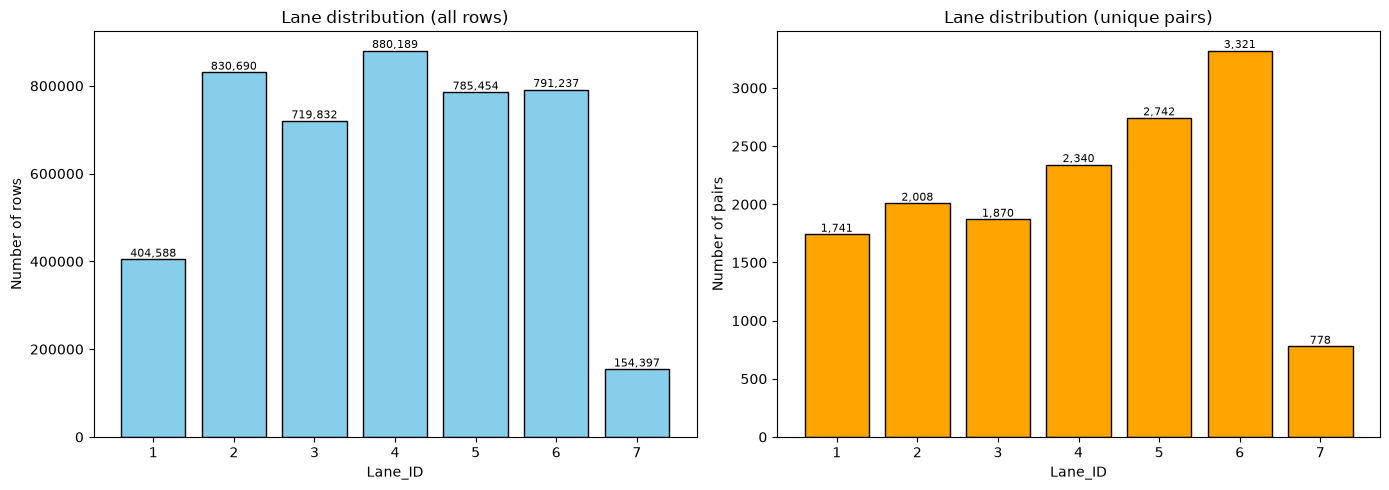

=== 行数ベース ===
Lane_ID
1    404588
2    830690
3    719832
4    880189
5    785454
6    791237
7    154397
Name: count, dtype: int64

=== ペア数ベース ===
Lane_ID
1    1741
2    2008
3    1870
4    2340
5    2742
6    3321
7     778
Name: count, dtype: int64

追従時間の分布:


In [ ]:
#df_with_pairsの車線分布
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 行数ベースの車線分布（Preceding=0の無効行も含む全体像）
lane_row_counts = df_with_pairs['Lane_ID'].value_counts().sort_index()
axes[0].bar(lane_row_counts.index.astype(str), lane_row_counts.values, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Lane_ID')
axes[0].set_ylabel('Number of rows')
axes[0].set_title('Lane distribution (all rows)')
for i, v in enumerate(lane_row_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)

# ペア数ベースの車線分布（有効なペアのみ、1ペア=1カウント）
valid_pairs = df_with_pairs.dropna(subset=['pair_id'])
lane_pair_counts = valid_pairs.groupby('pair_id')['Lane_ID'].first().value_counts().sort_index()
axes[1].bar(lane_pair_counts.index.astype(str), lane_pair_counts.values, color='orange', edgecolor='black')
axes[1].set_xlabel('Lane_ID')
axes[1].set_ylabel('Number of pairs')
axes[1].set_title('Lane distribution (unique pairs)')
for i, v in enumerate(lane_pair_counts.values):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("=== 行数ベース ===")
print(lane_row_counts)
print("\n=== ペア数ベース ===")
print(lane_pair_counts)


ペア総数: 14,800
60秒以上: 2,102
60秒未満: 12,698


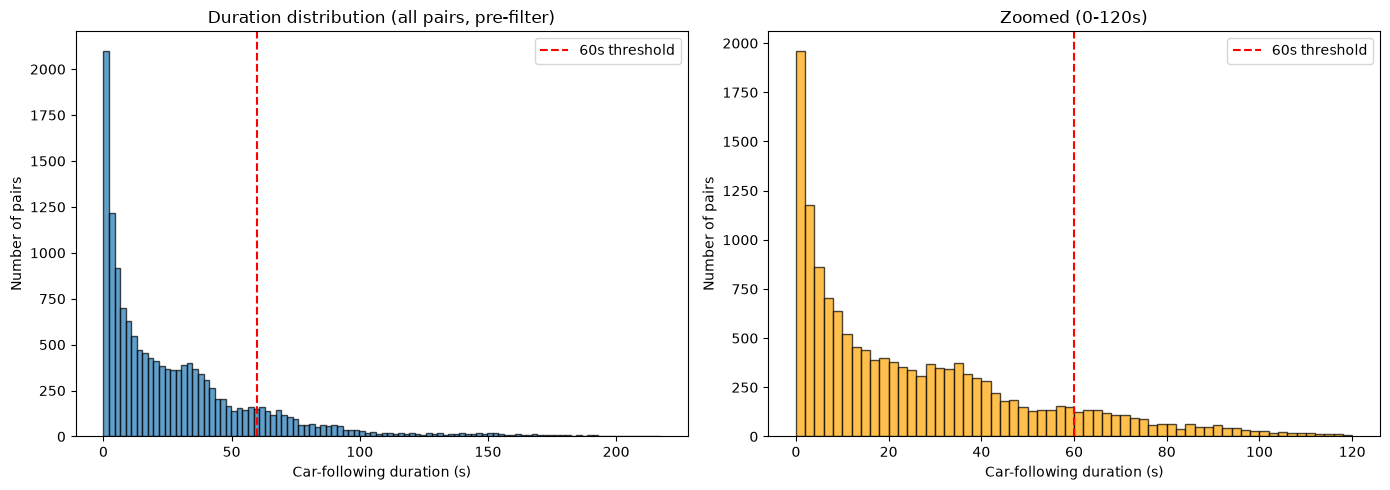

In [125]:
import matplotlib.pyplot as plt

def plot_duration_histogram(df, pair_col='pair_id', duration_threshold=60):
    valid = df.dropna(subset=[pair_col])
    pair_duration = valid.groupby(pair_col)['Global_Time'].agg(
        duration_sec=lambda x: (x.max() - x.min()) / 1000
    )

    print(f"ペア総数: {len(pair_duration):,}")
    print(f"{duration_threshold}秒以上: {(pair_duration['duration_sec'] >= duration_threshold).sum():,}")
    print(f"{duration_threshold}秒未満: {(pair_duration['duration_sec'] < duration_threshold).sum():,}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 全体分布
    axes[0].hist(pair_duration['duration_sec'], bins=100, edgecolor='black', alpha=0.7)
    axes[0].axvline(duration_threshold, color='red', linestyle='--', label=f'{duration_threshold}s threshold')
    axes[0].set_xlabel('Car-following duration (s)')
    axes[0].set_ylabel('Number of pairs')
    axes[0].set_title('Duration distribution (all pairs, pre-filter)')
    axes[0].legend()

    # 0〜120秒の拡大
    near = pair_duration[pair_duration['duration_sec'] <= 120]
    axes[1].hist(near['duration_sec'], bins=60, edgecolor='black', alpha=0.7, color='orange')
    axes[1].axvline(duration_threshold, color='red', linestyle='--', label=f'{duration_threshold}s threshold')
    axes[1].set_xlabel('Car-following duration (s)')
    axes[1].set_ylabel('Number of pairs')
    axes[1].set_title('Zoomed (0-120s)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return pair_duration

pair_duration = plot_duration_histogram(df_with_pairs)

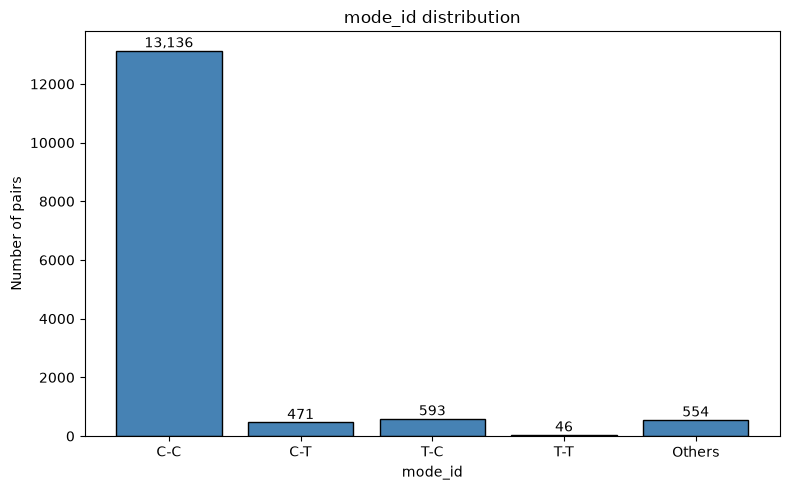

C-C       13136
C-T         471
T-C         593
T-T          46
Others      554
Name: count, dtype: int64


In [128]:
#モードIDの分布を可視化
import matplotlib.pyplot as plt
import pandas as pd

mode_labels = {1: 'C-C', 2: 'C-T', 3: 'T-C', 4: 'T-T', 5: 'Others'}

valid = df_with_mode.dropna(subset=['pair_id'])
pair_modes = valid.groupby('pair_id')['mode_id'].first()

mode_counts = pair_modes.value_counts(dropna=False).sort_index()
mode_counts.index = [
    mode_labels.get(i, '不明(leader未解決)') if pd.notna(i) else '不明(leader未解決)'
    for i in mode_counts.index
]

plt.figure(figsize=(8, 5))
bars = plt.bar(mode_counts.index.astype(str), mode_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('mode_id')
plt.ylabel('Number of pairs')
plt.title('mode_id distribution')
for bar, v in zip(bars, mode_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(mode_counts)

### 追従関係のある車両だけのdfを作る

In [118]:
def filter_valid_pairs(df):
    """
    pair_idとmode_idが付与されている行のみ残す関数
    （追従関係がない行を除外）
    """
    df_filtered = df.dropna(subset=['pair_id']).copy()
    
    print(f"フィルタ前の行数: {len(df):,}")
    print(f"フィルタ後の行数: {len(df_filtered):,}")
    print(f"除外された行数: {len(df) - len(df_filtered):,}")
    print(f"\nペア数: {df_filtered['pair_id'].nunique():,}")
    
    return df_filtered

# 実行
df_valid = filter_valid_pairs(df_with_mode)

フィルタ前の行数: 4,566,387
フィルタ後の行数: 4,359,292
除外された行数: 207,095

ペア数: 14,800


### 車線フィルタ

In [122]:
def filter_lane(df, lanes=[2, 3, 4]):
    """
    車線フィルタ
    lanes: 使用する車線のリスト（デフォルト: Lane 2,3,4）
    """
    df_filtered = df[df['Lane_ID'].isin(lanes)]
    
    print(f"フィルタ前: {len(df):,}行")
    print(f"フィルタ後: {len(df_filtered):,}行")
    print(f"除外された行数: {len(df) - len(df_filtered):,}行")
    
    print(f"\n車線の分布:")
    print(df_filtered['Lane_ID'].value_counts().sort_index())
    
    return df_filtered

In [123]:
# 実行
df_lane_with_pairs = filter_lane(df_valid)

# 追従ペア数の確認
print(f"追従ペア数: {df_lane_with_pairs['pair_id'].nunique():,}")

フィルタ前: 4,359,292行
フィルタ後: 2,338,989行
除外された行数: 2,020,303行

車線の分布:
Lane_ID
2    800434
3    689328
4    849227
Name: count, dtype: int64
追従ペア数: 6,218


### 車種フィルタ

In [126]:
def filter_mode(df, modes=[1,2,3,4]):
    """
    特定のモードIDのみを残すフィルタ（ペア単位で安全に処理）
    modes: 使用するモードIDのリスト
    デフォルト: [1,2,3,4]
    """
    
    # 1. 各ペアIDの代表モードIDを取得（最初の行の値を使う）
    pair_modes = df.dropna(subset=['pair_id']).groupby('pair_id')['mode_id'].first()
    
    # 2. 指定したモード(1,2,3,4)に該当する「ペアIDのリスト」を作成
    valid_pair_ids = pair_modes[pair_modes.isin(modes)].index
    
    # 3. 元のデータから、その有効なペアIDの行を丸ごと残す
    df_filtered = df[df['pair_id'].isin(valid_pair_ids)]
    
    
    print(f"フィルタ前のペア数: {df['pair_id'].nunique():,}")
    print(f"フィルタ後のペア数: {df_filtered['pair_id'].nunique():,}")
    print(f"除外されたペア数: {df['pair_id'].nunique() - df_filtered['pair_id'].nunique():,}")
    print(f"\nモードID別ペア数:")
    pairs_count = df_filtered.groupby(['pair_id', 'mode_id']).size().reset_index()
    print(pairs_count.groupby('mode_id').size())
    
    return df_filtered

# 実行（モードIDが5のペアを除外）
df_mode_filtered = filter_mode(df_lane_with_pairs)
print(f"フィルタ後: {len(df_mode_filtered):,}行")
 

フィルタ前のペア数: 6,218
フィルタ後のペア数: 6,053
除外されたペア数: 165

モードID別ペア数:
mode_id
1.0    5400
2.0     259
3.0     355
4.0      39
dtype: int64
フィルタ後: 2,335,404行


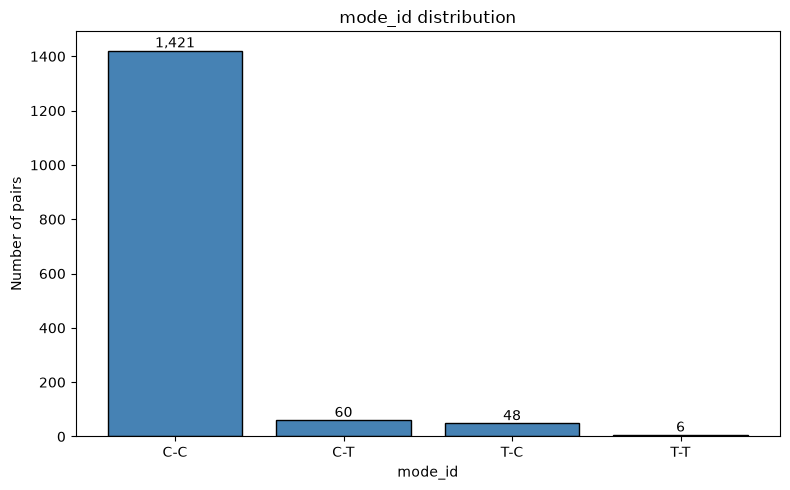

C-C    1421
C-T      60
T-C      48
T-T       6
Name: count, dtype: int64


In [ ]:
#モードIDの分布を可視化
import matplotlib.pyplot as plt
import pandas as pd

mode_labels = {1: 'C-C', 2: 'C-T', 3: 'T-C', 4: 'T-T', 5: 'Others'}

valid = df_mode_filtered.dropna(subset=['pair_id'])
pair_modes = valid.groupby('pair_id')['mode_id'].first()

mode_counts = pair_modes.value_counts(dropna=False).sort_index()
mode_counts.index = [
    mode_labels.get(i, '不明(leader未解決)') if pd.notna(i) else '不明(leader未解決)'
    for i in mode_counts.index
]

plt.figure(figsize=(8, 5))
bars = plt.bar(mode_counts.index.astype(str), mode_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('mode_id')
plt.ylabel('Number of pairs')
plt.title('mode_id distribution')
for bar, v in zip(bars, mode_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(mode_counts)

### 追従時間フィルタ

In [134]:
def filter_duration(df, min_duration=60):
    """
    追従時間フィルタ
    min_duration: 最小追従時間（秒）（デフォルト: 60秒）
    """
    # 各ペアの追従時間を計算
    pair_duration = df.groupby('pair_id')['Global_Time'].agg(
        duration=lambda x: (x.max() - x.min()) / 1000  + 0.1 # ミリ秒→秒
    )
    
    # min_duration以上のペアIDを取得
    valid_pair_ids = pair_duration[pair_duration['duration'] >= min_duration].index
    
    # 有効なペアIDの行だけ残す
    df_filtered = df[df['pair_id'].isin(valid_pair_ids)]
    
    print(f"フィルタ前のペア数: {df['pair_id'].nunique():,}")
    print(f"フィルタ後のペア数: {df_filtered['pair_id'].nunique():,}")
    print(f"除外されたペア数: {df['pair_id'].nunique() - df_filtered['pair_id'].nunique():,}")
    print(f"\nフィルタ前の行数: {len(df):,}")
    print(f"フィルタ後の行数: {len(df_filtered):,}")
    
    return df_filtered

# df_lane_with_pairsに対して実行
df_duration = filter_duration(df_mode_filtered, min_duration=60)

フィルタ前のペア数: 6,053
フィルタ後のペア数: 1,543
除外されたペア数: 4,510

フィルタ前の行数: 2,335,404
フィルタ後の行数: 1,460,862


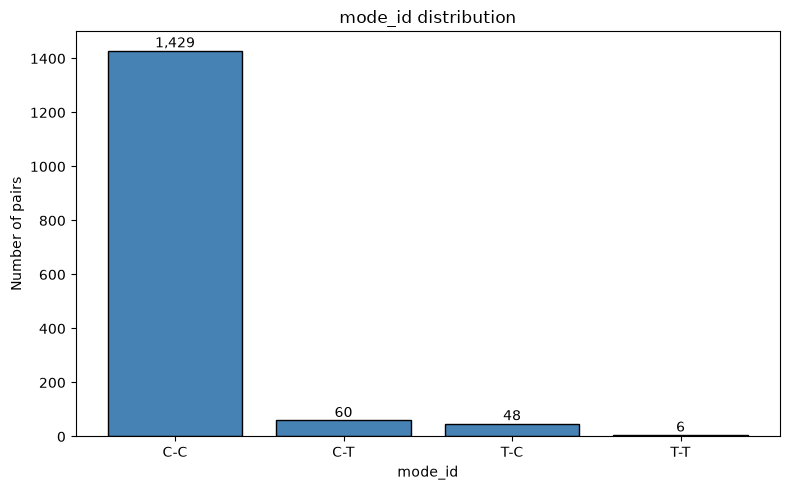

C-C    1429
C-T      60
T-C      48
T-T       6
Name: count, dtype: int64


In [139]:
#モードIDの分布を可視化
import matplotlib.pyplot as plt
import pandas as pd

mode_labels = {1: 'C-C', 2: 'C-T', 3: 'T-C', 4: 'T-T', 5: 'Others'}

valid = df_duration.dropna(subset=['pair_id'])
pair_modes = valid.groupby('pair_id')['mode_id'].first()

mode_counts = pair_modes.value_counts(dropna=False).sort_index()
mode_counts.index = [
    mode_labels.get(i, '不明(leader未解決)') if pd.notna(i) else '不明(leader未解決)'
    for i in mode_counts.index
]

plt.figure(figsize=(8, 5))
bars = plt.bar(mode_counts.index.astype(str), mode_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('mode_id')
plt.ylabel('Number of pairs')
plt.title('mode_id distribution')
for bar, v in zip(bars, mode_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(mode_counts)

ペア総数: 1,543
60秒以上: 1,543
60秒未満: 0


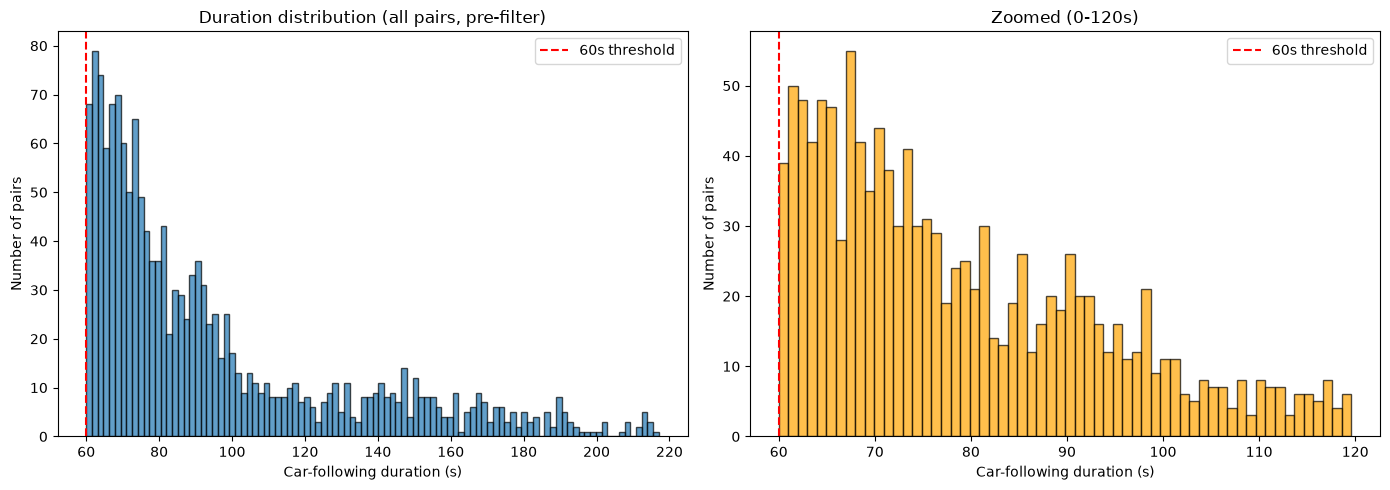

In [138]:
import matplotlib.pyplot as plt

def plot_duration_histogram(df, pair_col='pair_id', duration_threshold=60):
    valid = df.dropna(subset=[pair_col])
    pair_duration = valid.groupby(pair_col)['Global_Time'].agg(
        duration_sec=lambda x: (x.max() - x.min()) / 1000+0.1
    )

    print(f"ペア総数: {len(pair_duration):,}")
    print(f"{duration_threshold}秒以上: {(pair_duration['duration_sec'] >= duration_threshold).sum():,}")
    print(f"{duration_threshold}秒未満: {(pair_duration['duration_sec'] < duration_threshold).sum():,}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 全体分布
    axes[0].hist(pair_duration['duration_sec'], bins=100, edgecolor='black', alpha=0.7)
    axes[0].axvline(duration_threshold, color='red', linestyle='--', label=f'{duration_threshold}s threshold')
    axes[0].set_xlabel('Car-following duration (s)')
    axes[0].set_ylabel('Number of pairs')
    axes[0].set_title('Duration distribution (all pairs, pre-filter)')
    axes[0].legend()

    # 0〜120秒の拡大
    near = pair_duration[pair_duration['duration_sec'] <= 120]
    axes[1].hist(near['duration_sec'], bins=60, edgecolor='black', alpha=0.7, color='orange')
    axes[1].axvline(duration_threshold, color='red', linestyle='--', label=f'{duration_threshold}s threshold')
    axes[1].set_xlabel('Car-following duration (s)')
    axes[1].set_ylabel('Number of pairs')
    axes[1].set_title('Zoomed (0-120s)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return pair_duration

pair_duration = plot_duration_histogram(df_duration)

In [45]:
import pandas as pd

def analyze_pair_termination_reasons(df, pair_col='pair_id', duration_col=None, frame_interval=0.1):
    """
    各ペアの最終フレームの直後に何が起きて終了したかを分類する。
    - lane_changed: 車線変更
    - preceding_zero: 先行車を見失った(Preceding=0)
    - preceding_changed(real): 0を経由せず別の実車両IDに切り替わった
    - end_of_trajectory: 車両の記録自体がそこで終わっている
    """
    df = df.sort_values(['time_period', 'Vehicle_ID', 'Global_Time']).copy()
    grp = df.groupby(['Vehicle_ID', 'time_period'])
    df['next_Lane_ID'] = grp['Lane_ID'].shift(-1)
    df['next_Preceding'] = grp['Preceding'].shift(-1)

    pairs = df.dropna(subset=[pair_col]).groupby(pair_col).agg(
        duration_sec=(pair_col, 'size'),
        Lane_ID=('Lane_ID', 'last'),
        Preceding=('Preceding', 'last'),
        next_Lane_ID=('next_Lane_ID', 'last'),
        next_Preceding=('next_Preceding', 'last'),
    )
    pairs['duration_sec'] *= frame_interval

    def reason(row):
        if pd.isna(row['next_Preceding']):
            return 'end_of_trajectory'
        if row['next_Lane_ID'] != row['Lane_ID']:
            return 'lane_changed'
        if row['next_Preceding'] == 0:
            return 'preceding_zero'
        if row['next_Preceding'] != row['Preceding']:
            return 'preceding_changed(real)'
        return 'unknown'

    pairs['end_reason'] = pairs.apply(reason, axis=1)

    # 継続時間帯別に終了理由の内訳を見る
    pairs['duration_bucket'] = pd.cut(
        pairs['duration_sec'], bins=[0, 5, 20, 60, float('inf')],
        labels=['<5s', '5-20s', '20-60s', '>=60s']
    )
    summary = pd.crosstab(pairs['duration_bucket'], pairs['end_reason'])
    print(summary)
    print("\n=== 割合 ===")
    print(summary.div(summary.sum(axis=1), axis=0).round(3))

    return pairs

analyze_pair_termination_reasons(df_mode_filtered, pair_col='pair_id', duration_col=None, frame_interval=0.1)

end_reason       end_of_trajectory  lane_changed  preceding_changed(real)  \
duration_bucket                                                             
<5s                              9           182                      622   
5-20s                            0           251                      728   
20-60s                           0           218                      637   
>=60s                            0            74                      255   

end_reason       unknown  
duration_bucket           
<5s                  257  
5-20s                509  
20-60s               870  
>=60s               1216  

=== 割合 ===
end_reason       end_of_trajectory  lane_changed  preceding_changed(real)  \
duration_bucket                                                             
<5s                          0.008         0.170                    0.581   
5-20s                        0.000         0.169                    0.489   
20-60s                       0.000         0.126       

,duration_sec,Lane_ID,Preceding,next_Lane_ID,next_Preceding,end_reason,duration_bucket
pair_id,,,,,,,
470.0,8.2,2,3355.0,2.0,3355.0,unknown,5-20s
2258.0,83.9,2,1.0,2.0,1.0,unknown,>=60s
2284.0,0.5,2,117.0,2.0,117.0,unknown,<5s
2304.0,84.5,4,15.0,4.0,15.0,unknown,>=60s
3632.0,75.9,2,11.0,2.0,11.0,unknown,>=60s
...,...,...,...,...,...,...,...
221281.0,52.8,4,876.0,4.0,886.0,preceding_changed(real),20-60s
221282.0,4.3,4,886.0,4.0,881.0,preceding_changed(real),<5s
221283.0,6.4,4,881.0,4.0,886.0,preceding_changed(real),5-20s


### カットオフウィンドウ

In [140]:
def apply_cutoff(df, cutoff=10):
    """
    カットオフウィンドウ
    cutoff: カットオフ時間（秒）（デフォルト: 10秒）
    """
    cutoff_ms = cutoff * 1000  # 秒→ミリ秒
    
    # ペアごとの最小・最大時刻を計算
    pair_times = df.groupby('pair_id')['Global_Time'].agg(
        min_time='min',
        max_time='max'
    ).reset_index()
    
    # 元のデータに結合
    df_merged = df.merge(pair_times, on='pair_id')
    
    # カットオフ条件でフィルタリング
    df_filtered = df_merged[
        (df_merged['Global_Time'] >= df_merged['min_time'] + cutoff_ms) &
        (df_merged['Global_Time'] <= df_merged['max_time'] - cutoff_ms)
    ].drop(columns=['min_time', 'max_time'])
    
    print(f"カットオフ前の行数: {len(df):,}")
    print(f"カットオフ後の行数: {len(df_filtered):,}")
    print(f"除外された行数: {len(df) - len(df_filtered):,}")
    print(f"\nカットオフ前のペア数: {df['pair_id'].nunique():,}")
    print(f"カットオフ後のペア数: {df_filtered['pair_id'].nunique():,}")
    
    return df_filtered

# 実行
df_cutoff = apply_cutoff(df_duration)

カットオフ前の行数: 1,460,862
カットオフ後の行数: 1,152,262
除外された行数: 308,600

カットオフ前のペア数: 1,543
カットオフ後のペア数: 1,543


### 加速度フィルタ
加速度・減速度が1m/s^2 を超えた部分のみを削除する  <br>
NGSIMの単位: feet/s^2<br>
1 feet = 0.3048 m , 1 m = 3.28084 feet<br>
よって、1m/s^2 / 0.3048 = 3.28084 feet /s^2 を超える部分を削除する


In [142]:
def filter_acceleration(df, max_acc=1.0):
    """
    加速度フィルタ
    max_acc: 最大加速度・減速度（m/s²）（デフォルト: 1.0 m/s²）
    """
    # 閾値をfeet/s²に変換
    max_acc_feet = max_acc / 0.3048
    
    # 閾値を超える行を除外
    df_filtered = df[df['v_Acc'].abs() <= max_acc_feet]
    
    print(f"閾値: {max_acc} m/s² = {max_acc_feet:.4f} feet/s²")
    print(f"\nフィルタ前の行数: {len(df):,}")
    print(f"フィルタ後の行数: {len(df_filtered):,}")
    print(f"除外された行数: {len(df) - len(df_filtered):,}")
    print(f"\nフィルタ前のペア数: {df['pair_id'].nunique():,}")
    print(f"フィルタ後のペア数: {df_filtered['pair_id'].nunique():,}")
    
    return df_filtered

# 実行
df_acc = filter_acceleration(df_cutoff)

閾値: 1.0 m/s² = 3.2808 feet/s²

フィルタ前の行数: 1,152,262
フィルタ後の行数: 865,969
除外された行数: 286,293

フィルタ前のペア数: 1,543
フィルタ後のペア数: 1,543


#### 車線変更の確認 不要な気がする

In [145]:
def filter_lane_change(df):
    """
    車線変更フィルタ
    同じVehicle_ID・time_periodで車線変更が含まれる車両のペアを除外する
    """
    # Vehicle_ID・time_periodごとにLane_IDが変化しているか確認
    lane_changed_vehicles = df.groupby(['Vehicle_ID', 'time_period'])['Lane_ID'].apply(
        lambda x: x.nunique() > 1
    )
    
    # 車線変更があったVehicle_ID・time_periodを取得
    invalid = lane_changed_vehicles[lane_changed_vehicles].reset_index()[['Vehicle_ID', 'time_period']]
    
    # 該当する車両が含まれるpair_idを取得
    invalid_pairs = df.merge(invalid, on=['Vehicle_ID', 'time_period'], how='inner')['pair_id'].unique()
    
    # 無効なペアを除外
    df_filtered = df[~df['pair_id'].isin(invalid_pairs)]
    
    print(f"フィルタ前のペア数: {df['pair_id'].nunique():,}")
    print(f"除外されたペア数: {len(invalid_pairs):,}")
    print(f"フィルタ後のペア数: {df_filtered['pair_id'].nunique():,}")
    print(f"\nフィルタ前の行数: {len(df):,}")
    print(f"フィルタ後の行数: {len(df_filtered):,}")
    
    return df_filtered

# テストデータで確認
print("--- filter_lane_change テスト ---")
df_test_lc = filter_lane_change(df_acc)
print(df_test_lc[['Vehicle_ID', 'Global_Time', 'Lane_ID', 'Preceding', 'pair_id', 'mode_id']])

--- filter_lane_change テスト ---
フィルタ前のペア数: 1,543
除外されたペア数: 18
フィルタ後のペア数: 1,525

フィルタ前の行数: 865,969
フィルタ後の行数: 857,274
         Vehicle_ID    Global_Time  Lane_ID  Preceding  pair_id  mode_id
100              11  1113433150600        2          1     17.0      1.0
101              11  1113433150700        2          1     17.0      1.0
102              11  1113433150800        2          1     17.0      1.0
103              11  1113433150900        2          1     17.0      1.0
104              11  1113433151000        2          1     17.0      1.0
...             ...            ...      ...        ...      ...      ...
1460755        3006  1113437859900        4        479  21127.0      1.0
1460756        3006  1113437860000        4        479  21127.0      1.0
1460757        3006  1113437860100        4        479  21127.0      1.0
1460758        3006  1113437860200        4        479  21127.0      1.0
1460759        3006  1113437860300        4        479  21127.0      1.0

[857274 

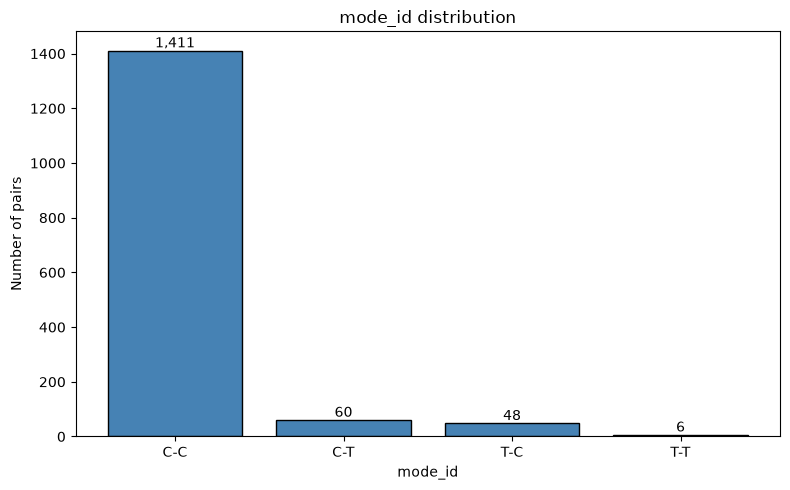

C-C    1411
C-T      60
T-C      48
T-T       6
Name: count, dtype: int64


In [146]:
#モードIDの分布を可視化
import matplotlib.pyplot as plt
import pandas as pd

mode_labels = {1: 'C-C', 2: 'C-T', 3: 'T-C', 4: 'T-T', 5: 'Others'}

valid = df_test_lc.dropna(subset=['pair_id'])
pair_modes = valid.groupby('pair_id')['mode_id'].first()

mode_counts = pair_modes.value_counts(dropna=False).sort_index()
mode_counts.index = [
    mode_labels.get(i, '不明(leader未解決)') if pd.notna(i) else '不明(leader未解決)'
    for i in mode_counts.index
]

plt.figure(figsize=(8, 5))
bars = plt.bar(mode_counts.index.astype(str), mode_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('mode_id')
plt.ylabel('Number of pairs')
plt.title('mode_id distribution')
for bar, v in zip(bars, mode_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(mode_counts)

## 実験

In [147]:
analyze_pair_termination_reasons(df_with_mode, pair_col='pair_id', duration_col=None, frame_interval=0.1)

end_reason       end_of_trajectory  lane_changed  preceding_changed(real)  \
duration_bucket                                                             
<5s                              1           711                     2296   
5-20s                            0           861                     1907   
20-60s                           0           555                     1566   
>=60s                            0           142                      445   

end_reason       preceding_zero  unknown  
duration_bucket                           
<5s                         569       14  
5-20s                      1181        5  
20-60s                     3009       23  
>=60s                      1500       15  

=== 割合 ===
end_reason       end_of_trajectory  lane_changed  preceding_changed(real)  \
duration_bucket                                                             
<5s                            0.0         0.198                    0.639   
5-20s                          0.0  

,duration_sec,Lane_ID,Preceding,next_Lane_ID,next_Preceding,end_reason,duration_bucket
pair_id,,,,,,,
2.0,8.2,2,3355,2.0,0.0,preceding_zero,5-20s
4.0,17.5,1,44,1.0,0.0,preceding_zero,5-20s
6.0,0.3,5,7,5.0,21.0,preceding_changed(real),<5s
7.0,31.0,5,21,5.0,0.0,preceding_zero,20-60s
12.0,3.0,5,21,6.0,5.0,lane_changed,<5s
...,...,...,...,...,...,...,...
21160.0,3.2,6,2343,6.0,2347.0,preceding_changed(real),<5s
21161.0,56.9,6,2347,6.0,2356.0,preceding_changed(real),20-60s
21162.0,4.5,6,2356,6.0,2361.0,preceding_changed(real),<5s


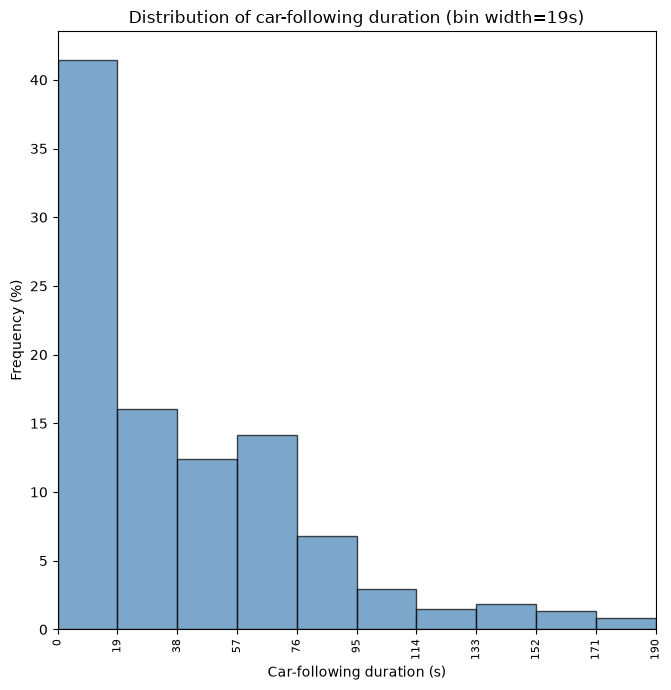

Number of pairs: 5,666
Pairs exceeding 190s (outside plot): 38
count    5666.000000
mean       41.118461
std        40.961587
min         0.000000
25%         8.500000
50%        28.300000
75%        63.175000
max       217.000000
Name: Global_Time, dtype: float64


In [12]:
import matplotlib.pyplot as plt
import numpy as np

valid = df_mode.dropna(subset=['pair_id'])
pair_duration = valid.groupby('pair_id')['Global_Time'].apply(lambda x: (x.max() - x.min()) / 1000)

bin_width = 19
x_max = 190
bins = np.arange(0, x_max + bin_width, bin_width)
weights = np.ones(len(pair_duration)) / len(pair_duration) * 100  # percent of all pairs

plt.figure(figsize=(7, 7))
plt.hist(pair_duration, bins=bins, weights=weights, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Car-following duration (s)')
plt.ylabel('Frequency (%)')
plt.title(f'Distribution of car-following duration (bin width={bin_width}s)')
plt.xlim(0, x_max)
plt.xticks(bins, rotation=90, fontsize=8)
plt.gca().set_box_aspect(1)  # square plot area
plt.tight_layout()
plt.show()

print(f"Number of pairs: {len(pair_duration):,}")
print(f"Pairs exceeding {x_max}s (outside plot): {(pair_duration > x_max).sum():,}")
print(pair_duration.describe())

In [8]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

%load_ext autoreload
%autoreload 2

# 現在のフォルダの「1つ上の階層（../）」をシステムのパスに追加する
sys.path.append(os.path.abspath(".."))

#作成したモジュールをインポート
from src.data_prep import *

df = load_trajectory_data()
df_clean_p = remove_flicker_noise(df, col='Preceding', threshold=10)
df_clean = remove_flicker_noise(df_clean_p, col='Lane_ID', threshold=10) 

# ① ペアID付与
df_with_pairs = give_pair_id(df_clean)

# ② モードID付与
df_with_mode = give_mode_id(df_with_pairs, df)

# ③ 追従していない行を除外 追従している車両のみのデータが完成
df_valid = filter_valid_pairs(df_with_mode)

# ④ 車線フィルタ（Lanes 2, 3, 4のみ）
df_lane = filter_lane(df_valid)

# ⑤ モードフィルタ
df_mode = filter_mode(df_lane)

# ⑥ 追従時間フィルタ
df_duration = filter_duration(df_mode)

# ⑧ カットオフウィンドウ
df_cutoff = apply_cutoff(df_duration)



# ⑦ 加速度フィルタ
df_final = filter_acceleration(df_cutoff).copy()


# 最終結果の確認
print(f"\n===最終結果===")
print(f"行数: {len(df_final):,}")
print(f"ペア数: {df_final['pair_id'].nunique():,}")
assign_and_count_pair_type(df_final)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
(4566387, 19)
フリッカリング除去完了
補正されたブロック数: 671
行数: 4,566,387
フリッカリング除去完了
補正されたブロック数: 142
行数: 4,566,387
モードID別ペア数:
mode_id
1.0    12337
2.0      438
3.0      549
4.0       42
5.0      461
dtype: int64
フィルタ前の行数: 4,566,387
フィルタ後の行数: 4,359,245
除外された行数: 207,142

ペア数: 13,827
フィルタ前: 4,359,245行
フィルタ後: 2,338,830行
除外された行数: 2,020,415行

車線の分布:
Lane_ID
2.0    800339
3.0    689350
4.0    849141
Name: count, dtype: int64
フィルタ前のペア数: 5,780
フィルタ後のペア数: 5,666
除外されたペア数: 114

モードID別ペア数:
mode_id
1.0    5067
2.0     237
3.0     326
4.0      36
dtype: int64
フィルタ前のペア数: 5,666
フィルタ後のペア数: 1,562
除外されたペア数: 4,104

フィルタ前の行数: 2,335,438
フィルタ後の行数: 1,483,054
カットオフ前の行数: 1,483,054
カットオフ後の行数: 1,170,654
除外された行数: 312,400

カットオフ前のペア数: 1,562
カットオフ後のペア数: 1,562
閾値: 1.0 m/s² = 3.2808 feet/s²

フィルタ前の行数: 1,170,654
フィルタ後の行数: 879,140
除外された行数: 291,514

フィルタ前のペア数: 1,562
フィルタ後のペア数: 1,562

===最終結果===
行数: 879,140
ペア数: 1,562
追従ペア数:
pair_type
C-C    1443
C-T   

,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,...,Preceding,Following,Space_Headway,Time_Headway,time_period,pair_id,leader_class,ego_class,mode_id,pair_type
100,11,157,864,1113433150600,15.236,130.989,6042830.240,2133199.574,17.3,8.4,...,1.0,0,43.76,5.83,1,17.0,2.0,2,1.0,C-C
101,11,158,864,1113433150700,15.212,131.739,6042830.123,2133200.315,17.3,8.4,...,1.0,0,44.06,5.87,1,17.0,2.0,2,1.0,C-C
102,11,159,864,1113433150800,15.188,132.489,6042830.006,2133201.056,17.3,8.4,...,1.0,0,44.36,5.91,1,17.0,2.0,2,1.0,C-C
103,11,160,864,1113433150900,15.163,133.239,6042829.889,2133201.797,17.3,8.4,...,1.0,0,44.66,5.95,1,17.0,2.0,2,1.0,C-C
104,11,161,864,1113433151000,15.139,133.990,6042829.772,2133202.539,17.3,8.4,...,1.0,0,44.96,5.99,1,17.0,2.0,2,1.0,C-C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1482947,3006,2950,828,1113437859900,42.358,1389.949,6042683.839,2134451.291,15.8,6.9,...,479.0,491,31.61,2.64,3,20091.0,2.0,2,1.0,C-C
1482948,3006,2951,828,1113437860000,42.352,1391.149,6042683.641,2134452.475,15.8,6.9,...,479.0,491,31.91,2.66,3,20091.0,2.0,2,1.0,C-C
1482949,3006,2952,828,1113437860100,42.345,1392.350,6042683.443,2134453.658,15.8,6.9,...,479.0,491,32.19,2.69,3,20091.0,2.0,2,1.0,C-C
1482950,3006,2953,828,1113437860200,42.340,1393.544,6042683.246,2134454.842,15.8,6.9,...,479.0,491,32.49,2.71,3,20091.0,2.0,2,1.0,C-C


In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

%load_ext autoreload
%autoreload 2

# 現在のフォルダの「1つ上の階層（../）」をシステムのパスに追加する
sys.path.append(os.path.abspath(".."))

#作成したモジュールをインポート
from src.data_prep import *

df = load_trajectory_data()
df_clean_p = remove_flicker_noise(df, col='Preceding', threshold=50)
df_clean = remove_flicker_noise(df_clean_p, col='Lane_ID', threshold=50) 

# ① ペアID付与
df_with_pairs = give_pair_id(df_clean)

# ② モードID付与
df_with_mode = give_mode_id(df_with_pairs, df)

# ③ 追従していない行を除外 追従している車両のみのデータが完成
df_valid = filter_valid_pairs(df_with_mode)

# ④ 車線フィルタ（Lanes 2, 3, 4のみ）
df_lane = filter_lane(df_valid)

# ⑤ モードフィルタ
df_mode = filter_mode(df_lane)

# ⑥ 追従時間フィルタ
df_duration = filter_duration(df_mode)

# ⑧ カットオフウィンドウ
df_cutoff = apply_cutoff(df_duration)

# ⑦ 加速度フィルタ
df_final = filter_acceleration(df_cutoff).copy()


# 最終結果の確認
print(f"\n===最終結果===")
print(f"行数: {len(df_final):,}")
print(f"ペア数: {df_final['pair_id'].nunique():,}")
assign_and_count_pair_type(df_final)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
(4566387, 19)
フリッカリング除去完了
補正されたブロック数: 435
行数: 4,566,387
フリッカリング除去完了
補正されたブロック数: 95
行数: 4,566,387
モードID別ペア数:
mode_id
1.0    12554
2.0      452
3.0      562
4.0       43
5.0      501
dtype: int64
フィルタ前の行数: 4,566,387
フィルタ後の行数: 4,359,231
除外された行数: 207,156

ペア数: 14,112
フィルタ前: 4,359,231行
フィルタ後: 2,338,937行
除外された行数: 2,020,294行

車線の分布:
Lane_ID
2.0    800408
3.0    689335
4.0    849194
Name: count, dtype: int64
フィルタ前のペア数: 5,909
フィルタ後のペア数: 5,766
除外されたペア数: 143

モードID別ペア数:
mode_id
1.0    5152
2.0     246
3.0     332
4.0      36
dtype: int64
フィルタ前のペア数: 5,766
フィルタ後のペア数: 1,547
除外されたペア数: 4,219

フィルタ前の行数: 2,335,381
フィルタ後の行数: 1,469,076
カットオフ前の行数: 1,469,076
カットオフ後の行数: 1,159,676
除外された行数: 309,400

カットオフ前のペア数: 1,547
カットオフ後のペア数: 1,547
閾値: 1.0 m/s² = 3.2808 feet/s²

フィルタ前の行数: 1,159,676
フィルタ後の行数: 871,185
除外された行数: 288,491

フィルタ前のペア数: 1,547
フィルタ後のペア数: 1,547

===最終結果===
行数: 871,185
ペア数: 1,547
追従ペア数:
pair_type
C-C    1431
C-T    

,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,...,Preceding,Following,Space_Headway,Time_Headway,time_period,pair_id,leader_class,ego_class,mode_id,pair_type
100,11,157,864,1113433150600,15.236,130.989,6042830.240,2133199.574,17.3,8.4,...,1.0,0,43.76,5.83,1,17.0,2.0,2,1.0,C-C
101,11,158,864,1113433150700,15.212,131.739,6042830.123,2133200.315,17.3,8.4,...,1.0,0,44.06,5.87,1,17.0,2.0,2,1.0,C-C
102,11,159,864,1113433150800,15.188,132.489,6042830.006,2133201.056,17.3,8.4,...,1.0,0,44.36,5.91,1,17.0,2.0,2,1.0,C-C
103,11,160,864,1113433150900,15.163,133.239,6042829.889,2133201.797,17.3,8.4,...,1.0,0,44.66,5.95,1,17.0,2.0,2,1.0,C-C
104,11,161,864,1113433151000,15.139,133.990,6042829.772,2133202.539,17.3,8.4,...,1.0,0,44.96,5.99,1,17.0,2.0,2,1.0,C-C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1468969,3006,2950,828,1113437859900,42.358,1389.949,6042683.839,2134451.291,15.8,6.9,...,479.0,491,31.61,2.64,3,20406.0,2.0,2,1.0,C-C
1468970,3006,2951,828,1113437860000,42.352,1391.149,6042683.641,2134452.475,15.8,6.9,...,479.0,491,31.91,2.66,3,20406.0,2.0,2,1.0,C-C
1468971,3006,2952,828,1113437860100,42.345,1392.350,6042683.443,2134453.658,15.8,6.9,...,479.0,491,32.19,2.69,3,20406.0,2.0,2,1.0,C-C
1468972,3006,2953,828,1113437860200,42.340,1393.544,6042683.246,2134454.842,15.8,6.9,...,479.0,491,32.49,2.71,3,20406.0,2.0,2,1.0,C-C


In [8]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

%load_ext autoreload
%autoreload 2

# 現在のフォルダの「1つ上の階層（../）」をシステムのパスに追加する
sys.path.append(os.path.abspath(".."))

#作成したモジュールをインポート
from src.data_prep import *

#df = load_trajectory_data()
df_clean_p = remove_flicker_noise(df, col='Preceding', threshold=50)
df_clean = remove_flicker_noise(df_clean_p, col='Lane_ID', threshold=50) 

# ① ペアID付与
df_with_pairs = give_pair_id(df_clean)

# ② モードID付与
df_with_mode = give_mode_id(df_with_pairs, df)

# ③ 追従していない行を除外 追従している車両のみのデータが完成
df_valid = filter_valid_pairs(df_with_mode)

# ④ 車線フィルタ（Lanes 2, 3, 4のみ）
df_lane = filter_lane(df_valid)

# ⑤ モードフィルタ
df_mode = filter_mode(df_lane)

# ⑥ 追従時間フィルタ
df_duration = filter_duration(df_mode)

# ⑧ カットオフウィンドウ
df_cutoff = apply_cutoff(df_duration)

# ⑦ 加速度フィルタ
df_final = filter_acceleration(df_cutoff).copy()


# 最終結果の確認
print(f"\n===最終結果===")
print(f"行数: {len(df_final):,}")
print(f"ペア数: {df_final['pair_id'].nunique():,}")
assign_and_count_pair_type(df_final)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
フリッカリング除去完了
補正されたブロック数: 1,395
行数: 4,566,387
フリッカリング除去完了
補正されたブロック数: 243
行数: 4,566,387
モードID別ペア数:
mode_id
1.0    11758
2.0      416
3.0      531
4.0       40
5.0      384
dtype: int64
フィルタ前の行数: 4,566,387
フィルタ後の行数: 4,361,142
除外された行数: 205,245

ペア数: 13,129
フィルタ前: 4,361,142行
フィルタ後: 2,338,121行
除外された行数: 2,023,021行

車線の分布:
Lane_ID
2.0    799894
3.0    689226
4.0    849001
Name: count, dtype: int64
フィルタ前のペア数: 5,443
フィルタ後のペア数: 5,375
除外されたペア数: 68

モードID別ペア数:
mode_id
1.0    4800
2.0     227
3.0     314
4.0      34
dtype: int64
フィルタ前のペア数: 5,375
フィルタ後のペア数: 1,577
除外されたペア数: 3,798

フィルタ前の行数: 2,335,579
フィルタ後の行数: 1,508,130
カットオフ前の行数: 1,508,130
カットオフ後の行数: 1,192,730
除外された行数: 315,400

カットオフ前のペア数: 1,577
カットオフ後のペア数: 1,577
閾値: 1.0 m/s² = 3.2808 feet/s²

フィルタ前の行数: 1,192,730
フィルタ後の行数: 895,533
除外された行数: 297,197

フィルタ前のペア数: 1,577
フィルタ後のペア数: 1,577

===最終結果===
行数: 895,533
ペア数: 1,577
追従ペア数:
pair_type
C-C    1456
C-T      67
C-M    

,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,...,Preceding,Following,Space_Headway,Time_Headway,time_period,pair_id,leader_class,ego_class,mode_id,pair_type
100,11,157,864,1113433150600,15.236,130.989,6042830.240,2133199.574,17.3,8.4,...,1.0,0,43.76,5.83,1,13.0,2.0,2,1.0,C-C
101,11,158,864,1113433150700,15.212,131.739,6042830.123,2133200.315,17.3,8.4,...,1.0,0,44.06,5.87,1,13.0,2.0,2,1.0,C-C
102,11,159,864,1113433150800,15.188,132.489,6042830.006,2133201.056,17.3,8.4,...,1.0,0,44.36,5.91,1,13.0,2.0,2,1.0,C-C
103,11,160,864,1113433150900,15.163,133.239,6042829.889,2133201.797,17.3,8.4,...,1.0,0,44.66,5.95,1,13.0,2.0,2,1.0,C-C
104,11,161,864,1113433151000,15.139,133.990,6042829.772,2133202.539,17.3,8.4,...,1.0,0,44.96,5.99,1,13.0,2.0,2,1.0,C-C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508023,3006,2950,828,1113437859900,42.358,1389.949,6042683.839,2134451.291,15.8,6.9,...,479.0,491,31.61,2.64,3,19256.0,2.0,2,1.0,C-C
1508024,3006,2951,828,1113437860000,42.352,1391.149,6042683.641,2134452.475,15.8,6.9,...,479.0,491,31.91,2.66,3,19256.0,2.0,2,1.0,C-C
1508025,3006,2952,828,1113437860100,42.345,1392.350,6042683.443,2134453.658,15.8,6.9,...,479.0,491,32.19,2.69,3,19256.0,2.0,2,1.0,C-C
1508026,3006,2953,828,1113437860200,42.340,1393.544,6042683.246,2134454.842,15.8,6.9,...,479.0,491,32.49,2.71,3,19256.0,2.0,2,1.0,C-C


In [13]:
import pandas as pd

mode_labels = {1: 'C-C', 2: 'C-T', 3: 'T-C', 4: 'T-T', 5: 'Others'}

def count_mode_by_stage(stages):
    """
    stages: dict of {stage_name: dataframe}, each df must have 'pair_id' and 'mode_id' columns.
    Counts unique pairs per mode_id at each stage.
    """
    records = []
    for name, df in stages.items():
        valid = df.dropna(subset=['pair_id'])
        pair_modes = valid.groupby('pair_id')['mode_id'].first()

        row = {'stage': name}
        for mode_id, label in mode_labels.items():
            row[label] = int((pair_modes == mode_id).sum())
        row['Unresolved'] = int(pair_modes.isna().sum())
        row['Total'] = len(pair_modes)
        records.append(row)

    return pd.DataFrame(records)


stages = {
    '1. give_mode_id':        df_with_mode,
    '2. filter_valid_pairs':  df_valid,
    '3. filter_lane':         df_lane,
    '4. filter_mode':         df_mode,
    '5. filter_duration':     df_duration,
    '6. apply_cutoff':        df_cutoff,
    '7. filter_acceleration': df_final,
}

mode_count_df = count_mode_by_stage(stages)
print(mode_count_df.to_string(index=False))

                 stage   C-C  C-T  T-C  T-T  Others  Unresolved  Total
       1. give_mode_id 12337  438  549   42     461           0  13827
 2. filter_valid_pairs 12337  438  549   42     461           0  13827
        3. filter_lane  5067  237  326   36     114           0   5780
        4. filter_mode  5067  237  326   36       0           0   5666
    5. filter_duration  1443   65   48    6       0           0   1562
       6. apply_cutoff  1443   65   48    6       0           0   1562
7. filter_acceleration  1443   65   48    6       0           0   1562


In [14]:
import pandas as pd

mode_labels = {1: 'C-C', 2: 'C-T', 3: 'T-C', 4: 'T-T', 5: 'Others'}

def count_mode_rows_by_stage(stages):
    """
    stages: dict of {stage_name: dataframe}, each df must have 'mode_id' column.
    Counts rows (not unique pairs) per mode_id at each stage.
    """
    records = []
    for name, df in stages.items():
        row = {'stage': name}
        for mode_id, label in mode_labels.items():
            row[label] = int((df['mode_id'] == mode_id).sum())
        row['Unresolved'] = int(df['mode_id'].isna().sum())
        row['Total'] = len(df)
        records.append(row)

    return pd.DataFrame(records)


stages = {
    '1. give_mode_id':        df_with_mode,
    '2. filter_valid_pairs':  df_valid,
    '3. filter_lane':         df_lane,
    '4. filter_mode':         df_mode,
    '5. filter_duration':     df_duration,
    '6. apply_cutoff':        df_cutoff,
    '7. filter_acceleration': df_final,
}

mode_row_count_df = count_mode_rows_by_stage(stages)
print(mode_row_count_df.to_string(index=False))

                 stage     C-C    C-T    T-C   T-T  Others  Unresolved   Total
       1. give_mode_id 4020068 146002 142547 15652   34976      207142 4566387
 2. filter_valid_pairs 4020068 146002 142547 15652   34976           0 4359245
        3. filter_lane 2129431  96607  94775 14625    3392           0 2338830
        4. filter_mode 2129431  96607  94775 14625       0           0 2335438
    5. filter_duration 1372570  60701  43728  6055       0           0 1483054
       6. apply_cutoff 1083970  47701  34128  4855       0           0 1170654
7. filter_acceleration  812923  36231  26210  3776       0           0  879140


In [8]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

%load_ext autoreload
%autoreload 2

# 現在のフォルダの「1つ上の階層（../）」をシステムのパスに追加する
sys.path.append(os.path.abspath(".."))

#作成したモジュールをインポート
from src.data_prep import *

#df = load_trajectory_data()
df_clean_p = remove_flicker_noise(df_2, col='Preceding', threshold=5)
df_clean = remove_flicker_noise(df_clean_p, col='Lane_ID', threshold=5) 

# ① ペアID付与
df_with_pairs = give_pair_id(df_clean)

# ② モードID付与
df_with_mode = give_mode_id(df_with_pairs, df)

# ③ 追従していない行を除外 追従している車両のみのデータが完成
df_valid = filter_valid_pairs(df_with_mode)

# ④ 車線フィルタ（Lanes 2, 3, 4のみ）
df_lane = filter_lane(df_valid)

# ⑤ モードフィルタ
df_mode = filter_mode(df_lane)

# ⑥ 追従時間フィルタ
df_duration = filter_duration(df_mode)

# ⑧ カットオフウィンドウ
df_cutoff = apply_cutoff(df_duration)

# ⑦ 加速度フィルタ
df_final = filter_acceleration(df_cutoff).copy()


# 最終結果の確認
print(f"\n===最終結果===")
print(f"行数: {len(df_final):,}")
print(f"ペア数: {df_final['pair_id'].nunique():,}")
assign_and_count_pair_type(df_final)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
フリッカリング除去完了
補正されたブロック数: 123
行数: 1,549,918
フリッカリング除去完了
補正されたブロック数: 25
行数: 1,549,918
モードID別ペア数:
mode_id
1.0    4060
2.0     147
3.0     192
4.0       9
5.0     260
dtype: int64
フィルタ前の行数: 1,549,918
フィルタ後の行数: 1,483,559
除外された行数: 66,359

ペア数: 4,668
フィルタ前: 1,483,559行
フィルタ後: 795,359行
除外された行数: 688,200行

車線の分布:
Lane_ID
2.0    268517
3.0    230395
4.0    296447
Name: count, dtype: int64
フィルタ前のペア数: 1,828
フィルタ後のペア数: 1,766
除外されたペア数: 62

モードID別ペア数:
mode_id
1.0    1574
2.0      77
3.0     107
4.0       8
dtype: int64
フィルタ前のペア数: 1,766
フィルタ後のペア数: 575
除外されたペア数: 1,191

フィルタ前の行数: 794,015
フィルタ後の行数: 553,209
カットオフ前の行数: 553,209
カットオフ後の行数: 438,209
除外された行数: 115,000

カットオフ前のペア数: 575
カットオフ後のペア数: 575
閾値: 1.0 m/s² = 3.2808 feet/s²

フィルタ前の行数: 438,209
フィルタ後の行数: 338,453
除外された行数: 99,756

フィルタ前のペア数: 575
フィルタ後のペア数: 575

===最終結果===
行数: 338,453
ペア数: 575
追従ペア数:
pair_type
C-C    523
C-T     26
C-M      0
T-T      2
T-C     24
T-M      0
M-

,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,...,Preceding,Following,Space_Headway,Time_Headway,time_period,pair_id,leader_class,ego_class,mode_id,pair_type
100,306,181,603,1113436785000,29.303,414.244,6042809.601,2133482.224,15.8,6.9,...,295.0,315,40.68,1.48,2,27.0,2.0,2,1.0,C-C
101,306,182,603,1113436785100,29.292,417.014,6042809.255,2133485.027,15.8,6.9,...,295.0,315,40.46,1.47,2,27.0,2.0,2,1.0,C-C
102,306,183,603,1113436785200,29.274,419.765,6042808.884,2133488.021,15.8,6.9,...,295.0,315,40.37,1.47,2,27.0,2.0,2,1.0,C-C
103,306,184,603,1113436785300,29.329,422.482,6042808.516,2133491.000,15.8,6.9,...,295.0,315,40.44,1.47,2,27.0,2.0,2,1.0,C-C
107,306,188,603,1113436785700,29.539,434.010,6042807.110,2133502.384,15.8,6.9,...,295.0,315,40.31,1.33,2,27.0,2.0,2,1.0,C-C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553096,2860,9595,1462,1113437726400,41.713,1472.721,6042669.930,2134532.947,14.8,6.4,...,2837.0,0,54.78,2.31,2,6652.0,2.0,2,1.0,C-C
553097,2860,9596,1462,1113437726500,41.705,1475.095,6042669.539,2134535.290,14.8,6.4,...,2837.0,0,55.12,2.32,2,6652.0,2.0,2,1.0,C-C
553098,2860,9597,1462,1113437726600,41.696,1477.471,6042669.148,2134537.632,14.8,6.4,...,2837.0,0,55.45,2.33,2,6652.0,2.0,2,1.0,C-C
553099,2860,9598,1462,1113437726700,41.688,1479.847,6042668.757,2134539.975,14.8,6.4,...,2837.0,0,55.80,2.35,2,6652.0,2.0,2,1.0,C-C


In [9]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

%load_ext autoreload
%autoreload 2

# 現在のフォルダの「1つ上の階層（../）」をシステムのパスに追加する
sys.path.append(os.path.abspath(".."))

#作成したモジュールをインポート
from src.data_prep import *

#df = load_trajectory_data()
df_clean_p = remove_flicker_noise(df_3, col='Preceding', threshold=5)
df_clean = remove_flicker_noise(df_clean_p, col='Lane_ID', threshold=5) 

# ① ペアID付与
df_with_pairs = give_pair_id(df_clean)

# ② モードID付与
df_with_mode = give_mode_id(df_with_pairs, df)

# ③ 追従していない行を除外 追従している車両のみのデータが完成
df_valid = filter_valid_pairs(df_with_mode)

# ④ 車線フィルタ（Lanes 2, 3, 4のみ）
df_lane = filter_lane(df_valid)

# ⑤ モードフィルタ
df_mode = filter_mode(df_lane)

# ⑥ 追従時間フィルタ
df_duration = filter_duration(df_mode)

# ⑧ カットオフウィンドウ
df_cutoff = apply_cutoff(df_duration)

# ⑦ 加速度フィルタ
df_final = filter_acceleration(df_cutoff).copy()


# 最終結果の確認
print(f"\n===最終結果===")
print(f"行数: {len(df_final):,}")
print(f"ペア数: {df_final['pair_id'].nunique():,}")
assign_and_count_pair_type(df_final)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
フリッカリング除去完了
補正されたブロック数: 123
行数: 1,753,791
フリッカリング除去完了
補正されたブロック数: 19
行数: 1,753,791
モードID別ペア数:
mode_id
1.0    4256
2.0     104
3.0     121
4.0       4
5.0     194
dtype: int64
フィルタ前の行数: 1,753,791
フィルタ後の行数: 1,680,230
除外された行数: 73,561

ペア数: 4,679
フィルタ前: 1,680,230行
フィルタ後: 889,961行
除外された行数: 790,269行

車線の分布:
Lane_ID
2.0    301342
3.0    270047
4.0    318572
Name: count, dtype: int64
フィルタ前のペア数: 2,007
フィルタ後のペア数: 1,928
除外されたペア数: 79

モードID別ペア数:
mode_id
1.0    1797
2.0      57
3.0      70
4.0       4
dtype: int64
フィルタ前のペア数: 1,928
フィルタ後のペア数: 597
除外されたペア数: 1,331

フィルタ前の行数: 887,774
フィルタ後の行数: 651,826
カットオフ前の行数: 651,826
カットオフ後の行数: 532,426
除外された行数: 119,400

カットオフ前のペア数: 597
カットオフ後のペア数: 597
閾値: 1.0 m/s² = 3.2808 feet/s²

フィルタ前の行数: 532,426
フィルタ後の行数: 405,203
除外された行数: 127,223

フィルタ前のペア数: 597
フィルタ後のペア数: 597

===最終結果===
行数: 405,203
ペア数: 597
追従ペア数:
pair_type
C-C    558
C-T     19
C-M      0
T-T      1
T-C     19
T-M      0
M

,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,...,Preceding,Following,Space_Headway,Time_Headway,time_period,pair_id,leader_class,ego_class,mode_id,pair_type
100,8,1033,1171,1113437668200,17.648,565.478,6042779.252,2133631.084,14.3,7.4,...,3.0,42,43.94,2.38,3,9.0,2.0,2,1.0,C-C
101,8,1034,1171,1113437668300,17.627,567.328,6042779.000,2133632.917,14.3,7.4,...,3.0,42,43.82,2.37,3,9.0,2.0,2,1.0,C-C
102,8,1035,1171,1113437668400,17.606,569.178,6042778.748,2133634.750,14.3,7.4,...,3.0,42,43.71,2.36,3,9.0,2.0,2,1.0,C-C
103,8,1036,1171,1113437668500,17.584,571.027,6042778.495,2133636.583,14.3,7.4,...,3.0,42,43.59,2.35,3,9.0,2.0,2,1.0,C-C
104,8,1037,1171,1113437668600,17.563,572.880,6042778.243,2133638.416,14.3,7.4,...,3.0,42,43.48,2.35,3,9.0,2.0,2,1.0,C-C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651719,3006,2950,828,1113437859900,42.358,1389.949,6042683.839,2134451.291,15.8,6.9,...,479.0,491,31.61,2.64,3,6661.0,2.0,2,1.0,C-C
651720,3006,2951,828,1113437860000,42.352,1391.149,6042683.641,2134452.475,15.8,6.9,...,479.0,491,31.91,2.66,3,6661.0,2.0,2,1.0,C-C
651721,3006,2952,828,1113437860100,42.345,1392.350,6042683.443,2134453.658,15.8,6.9,...,479.0,491,32.19,2.69,3,6661.0,2.0,2,1.0,C-C
651722,3006,2953,828,1113437860200,42.340,1393.544,6042683.246,2134454.842,15.8,6.9,...,479.0,491,32.49,2.71,3,6661.0,2.0,2,1.0,C-C


In [5]:
#TTペアが多い理由を調査
tt_rows = df_final[df_final['mode_id'] == 4].sort_values(['pair_id', 'Global_Time'])
tt_rows.to_csv('../results/tt_pairs.csv', index=False)

print(f"T-Tペアの行数: {len(tt_rows):,}")
print(f"T-Tペア数: {tt_rows['pair_id'].nunique():,}")
print(f"出力先: results/tt_pairs.csv")

T-Tペアの行数: 3,776
T-Tペア数: 6
出力先: results/tt_pairs.csv


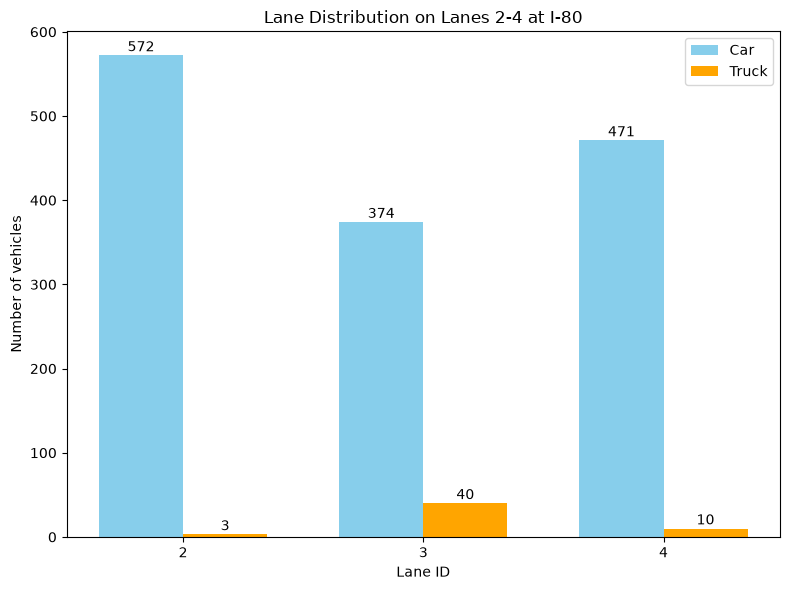

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 解析に使うベースデータを明示的に定義
base_df = df_final.copy()

# ★修正1：Lane 2, 3, 4 のデータだけに絞り込む
base_df = base_df[base_df['Lane_ID'].isin([2, 3, 4])]

# 車線ごとの車両数を集計
base_df = base_df.drop_duplicates(subset=['Vehicle_ID', 'time_period', 'Lane_ID'])
lane_class = base_df.groupby(['Lane_ID', 'v_Class'])['Vehicle_ID'].nunique().reset_index()

# ★修正2：pivotを使って行をLane_ID、列をv_Classのクロス集計表にする
# （データがない組み合わせは fillna(0) で0台として埋める）
pivot_df = lane_class.pivot(index='Lane_ID', columns='v_Class', values='Vehicle_ID').fillna(0)

# グラフ描画
x = pivot_df.index.to_numpy() # [2, 3, 4] が自動で入る
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))

# ★修正3：抽出したpivotの表から安全に値を取り出す
# （万が一、車かトラックのどちらかが0台で列が存在しなくてもエラーを回避）
cars_vals = pivot_df[2].values if 2 in pivot_df.columns else np.zeros(len(x))
trucks_vals = pivot_df[3].values if 3 in pivot_df.columns else np.zeros(len(x))

bars_car = ax.bar(x - width/2, cars_vals, width, label='Car', color='skyblue')
bars_truck = ax.bar(x + width/2, trucks_vals, width, label='Truck', color='orange')

# 値をバーの上に表示
for bar in bars_car:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', va='bottom')

for bar in bars_truck:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', va='bottom')

ax.set_xlabel('Lane ID')
ax.set_ylabel('Number of vehicles')
ax.set_xticks(x)
ax.legend()
ax.set_title('Lane Distribution on Lanes 2-4 at I-80')
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

waterfall_records = []



def record(stage_name, df, has_pair_id=True):
    waterfall_records.append({
        'stage': stage_name,
        'rows': len(df),
        'pairs': df['pair_id'].nunique() if (has_pair_id and 'pair_id' in df.columns) else np.nan,
    })

df = load_trajectory_data()
record('0. 生データ読み込み', df, has_pair_id=False)

df_clean = remove_flicker_noise(df, col='Preceding', threshold=5)
df_clean = remove_flicker_noise(df_clean, col='Lane_ID', threshold=5)
record('1. ノイズ除去(Preceding/Lane_ID)', df_clean, has_pair_id=False)

df_with_pairs = give_pair_id(df_clean)
record('2. ペアID付与', df_with_pairs)

df_with_mode = give_mode_id(df_with_pairs, df)
record('3. モードID付与', df_with_mode)

df_valid = filter_valid_pairs(df_with_mode)
record('4. 非追従行(Preceding=0等)除外', df_valid)

df_lane = filter_lane(df_valid)
record('5. 車線フィルタ(Lane 2-4)', df_lane)

df_mode = filter_mode(df_lane)
record('6. モードフィルタ(C/T以外除外)', df_mode)

df_duration = filter_duration(df_mode, min_duration=60)
record('7. 追従時間フィルタ(60s以上)', df_duration)

df_cutoff = apply_cutoff(df_duration, cutoff=10)
record('8. カットオフ(前後10s除外)', df_cutoff)

df_final = filter_acceleration(df_cutoff, max_acc=1.0).copy()
record('9. 加速度フィルタ(|a|<=1m/s^2)', df_final)


# ============================================================
# テーブル化
# ============================================================
waterfall_df = pd.DataFrame(waterfall_records)
waterfall_df['行数減少'] = (-waterfall_df['rows'].diff()).fillna(0).astype(int)
waterfall_df['ペア数減少'] = (-waterfall_df['pairs'].diff()).fillna(0)
waterfall_df['ペア残存率(%)'] = (waterfall_df['pairs'] / waterfall_df['pairs'].iloc[2] * 100).round(1)  # ②を100%基準

print(waterfall_df.to_string(index=False))


# ============================================================
# 可視化（ペア数の推移=ファネル）
# ============================================================
plot_df = waterfall_df.dropna(subset=['pairs'])

plt.figure(figsize=(11, 5))
bars = plt.bar(plot_df['stage'], plot_df['pairs'], color='steelblue', edgecolor='black')
for bar, v in zip(bars, plot_df['pairs']):
    plt.text(bar.get_x() + bar.get_width()/2, v, f'{int(v):,}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of pairs')
plt.title('フィルタリング段階別 ペア数の推移（ウォーターフォール）')
plt.tight_layout()
plt.show()

NameError: name 'load_trajectory_data' is not defined

対象ペア数(C-T,T-C,T-T): 116
最小スペーシングが負のペア数: 0
最小スペーシングが1.5m未満のペア数: 0

=== 怪しい順 上位15件 ===
         mode_id  min_spacing_m  mean_spacing_m  frames_negative  n_frames
pair_id                                                                   
12210.0      3.0           2.30            9.75                0       515
17987.0      3.0           3.10           20.30                0       434
19417.0      2.0           4.10           23.99                0      1411
8498.0       3.0           5.03           16.68                0       308
11397.0      3.0           5.27           11.36                0       504
15397.0      3.0           5.52           11.80                0       599
5369.0       3.0           5.64           24.29                0       322
15786.0      3.0           5.80           14.15                0       492
18227.0      3.0           6.12           11.24                0       952
12604.0      3.0           6.22           12.17                0       416
7773.0       3.

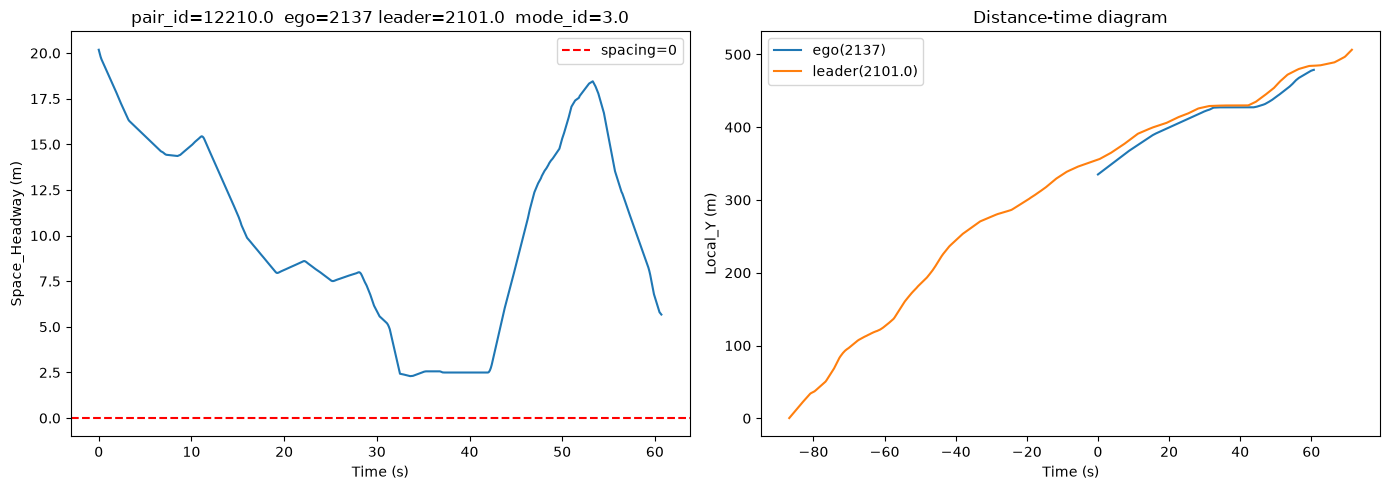

In [152]:
import matplotlib.pyplot as plt

# ============================================================
# ① スクリーニング：スペーシング異常の疑いが強いペアをランキング
# ============================================================
def screen_collision_candidates(df, mode_ids=(2, 3, 4), space_col='Space_Headway'):
    """
    トラック絡み(C-T=2, T-C=3, T-T=4)のペアに絞り、
    Space_Headwayが異常に小さい/負になる区間がないかスクリーニングする。
    """
    target = df[df['mode_id'].isin(mode_ids)].dropna(subset=['pair_id'])

    stats = target.groupby('pair_id').agg(
        mode_id=('mode_id', 'first'),
        min_spacing_ft=(space_col, 'min'),
        mean_spacing_ft=(space_col, 'mean'),
        frames_negative=(space_col, lambda x: (x < 0).sum()),
        frames_near_zero=(space_col, lambda x: (x < 5).sum()),  # 5ft ≈ 1.5m未満
        n_frames=(space_col, 'size'),
    )
    stats['min_spacing_m'] = (stats['min_spacing_ft'] * 0.3048).round(2)
    stats['mean_spacing_m'] = (stats['mean_spacing_ft'] * 0.3048).round(2)
    stats = stats.sort_values('min_spacing_m')

    print(f"対象ペア数(C-T,T-C,T-T): {len(stats):,}")
    print(f"最小スペーシングが負のペア数: {(stats['frames_negative'] > 0).sum():,}")
    print(f"最小スペーシングが1.5m未満のペア数: {(stats['frames_near_zero'] > 0).sum():,}")

    return stats


# ============================================================
# ② 個別ペアの距離-時間図（目視確認用）
# ============================================================
def plot_pair_diagram(pair_id, df_target, original_df, space_col='Space_Headway'):
    pair_rows = df_target[df_target['pair_id'] == pair_id].sort_values('Global_Time')
    ego_id = pair_rows['Vehicle_ID'].iloc[0]
    leader_id = pair_rows['Preceding'].iloc[0]
    tp = pair_rows['time_period'].iloc[0]
    mode_id = pair_rows['mode_id'].iloc[0]

    leader_rows = original_df[
        (original_df['Vehicle_ID'] == leader_id) & (original_df['time_period'] == tp)
    ].sort_values('Global_Time')

    t0 = pair_rows['Global_Time'].min()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # スペーシングの推移
    t_sec = (pair_rows['Global_Time'] - t0) / 1000
    axes[0].plot(t_sec, pair_rows[space_col] * 0.3048)
    axes[0].axhline(0, color='red', linestyle='--', label='spacing=0')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Space_Headway (m)')
    axes[0].set_title(f'pair_id={pair_id}  ego={ego_id} leader={leader_id}  mode_id={mode_id}')
    axes[0].legend()

    # 距離-時間図（両車両のLocal_Yを重ねる）
    axes[1].plot(t_sec, pair_rows['Local_Y'] * 0.3048, label=f'ego({ego_id})')
    if len(leader_rows) > 0:
        leader_t = (leader_rows['Global_Time'] - t0) / 1000
        axes[1].plot(leader_t, leader_rows['Local_Y'] * 0.3048, label=f'leader({leader_id})')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Local_Y (m)')
    axes[1].set_title('Distance-time diagram')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# 実行
# ============================================================
candidates = screen_collision_candidates(df_final)
print("\n=== 怪しい順 上位15件 ===")
print(candidates.head(15)[['mode_id', 'min_spacing_m', 'mean_spacing_m', 'frames_negative', 'n_frames']])

# 一番怪しいペアを実際にプロット
worst_pair_id = candidates.index[0]
plot_pair_diagram(worst_pair_id, df_final, df)  # df=load_trajectory_data()の生データ

In [153]:
import pandas as pd

def analyze_pair_termination_reasons(df, pair_col='pair_id', mode_col='mode_id', frame_interval=0.1):
    """
    filter_valid_pairsより前のdf_with_modeに対して実行すること
    （Preceding=0の行がまだ物理的に存在している必要があるため）
    """
    df = df.sort_values(['time_period', 'Vehicle_ID', 'Global_Time']).copy()
    grp = df.groupby(['Vehicle_ID', 'time_period'])
    df['next_Lane_ID'] = grp['Lane_ID'].shift(-1)
    df['next_Preceding'] = grp['Preceding'].shift(-1)

    pairs = df.dropna(subset=[pair_col]).groupby(pair_col).agg(
        duration_sec=(pair_col, 'size'),
        mode_id=(mode_col, 'first'),
        Lane_ID=('Lane_ID', 'last'),
        Preceding=('Preceding', 'last'),
        next_Lane_ID=('next_Lane_ID', 'last'),
        next_Preceding=('next_Preceding', 'last'),
    )
    pairs['duration_sec'] *= frame_interval

    def reason(row):
        if pd.isna(row['next_Preceding']):
            return 'end_of_trajectory'
        if row['next_Lane_ID'] != row['Lane_ID']:
            return 'lane_changed'
        if row['next_Preceding'] == 0:
            return 'preceding_zero'
        if row['next_Preceding'] != row['Preceding']:
            return 'preceding_changed(real)'
        return 'unknown'

    pairs['end_reason'] = pairs.apply(reason, axis=1)
    pairs['duration_bucket'] = pd.cut(
        pairs['duration_sec'], bins=[0, 5, 20, 60, float('inf')],
        labels=['<5s', '5-20s', '20-60s', '>=60s']
    )
    return pairs


# C-C(mode_id=1)だけに絞って集計
pairs = analyze_pair_termination_reasons(df_with_mode)
cc_pairs = pairs[pairs['mode_id'] == 1]

summary = pd.crosstab(cc_pairs['duration_bucket'], cc_pairs['end_reason'])
print(summary)
print("\n=== 割合 ===")
print(summary.div(summary.sum(axis=1), axis=0).round(3))

end_reason       lane_changed  preceding_changed(real)  preceding_zero  \
duration_bucket                                                          
<5s                       469                     1491             467   
5-20s                     760                     1604            1040   
20-60s                    515                     1424            2766   
>=60s                     133                      411            1422   

end_reason       unknown  
duration_bucket           
<5s                   13  
5-20s                  4  
20-60s                21  
>=60s                 14  

=== 割合 ===
end_reason       lane_changed  preceding_changed(real)  preceding_zero  \
duration_bucket                                                          
<5s                     0.192                    0.611           0.191   
5-20s                   0.223                    0.471           0.305   
20-60s                  0.109                    0.301           0.585   
>=60s      

In [154]:
def analyze_zero_gaps(df, col='Preceding'):
    df = df.sort_values(['time_period', 'Vehicle_ID', 'Global_Time']).copy()
    is_new_block = (
        (df['Vehicle_ID'] != df['Vehicle_ID'].shift()) |
        (df['time_period'] != df['time_period'].shift()) |
        (df[col] != df[col].shift())
    )
    df['_block_id'] = is_new_block.cumsum()

    blocks = df.groupby('_block_id').agg(
        Vehicle_ID=('Vehicle_ID', 'first'),
        time_period=('time_period', 'first'),
        value=(col, 'first'),
        frame_count=(col, 'size'),
    )
    blocks['prev_value'] = blocks.groupby(['Vehicle_ID', 'time_period'])['value'].shift(1)
    blocks['next_value'] = blocks.groupby(['Vehicle_ID', 'time_period'])['value'].shift(-1)

    zero_blocks = blocks[blocks['value'] == 0].copy()
    zero_blocks['same_leader_after'] = (
        (zero_blocks['prev_value'] == zero_blocks['next_value']) & zero_blocks['prev_value'].notna()
    )

    print(f"Preceding=0のブロック数: {len(zero_blocks):,}")

    bins = [0, 5, 10, 20, 50, float('inf')]
    labels = ['<=5f(補正済)', '6-10f', '11-20f', '21-50f', '51f+']
    zero_blocks['gap_bucket'] = pd.cut(zero_blocks['frame_count'], bins=bins, labels=labels)

    print("\n=== 0区間の長さ別: 前後で同じ先行車に戻る割合 ===")
    print(zero_blocks.groupby('gap_bucket')['same_leader_after'].agg(['sum', 'count', 'mean']))

    return zero_blocks

zero_blocks = analyze_zero_gaps(df_with_mode)

Preceding=0のブロック数: 6,274

=== 0区間の長さ別: 前後で同じ先行車に戻る割合 ===
            sum  count      mean
gap_bucket                      
<=5f(補正済)     2     88  0.022727
6-10f        16    239  0.066946
11-20f       41   1714  0.023921
21-50f       70   3565  0.019635
51f+         14    668  0.020958


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

def analyze_preceding_zero_duration(df):
    """
    Preceding=0（先行車なし）が何フレーム連続しているかの分布を出力する関数
    """
    print("Preceding=0 の連続フレーム数を集計中...")
    
    # 時間帯、車両ID、時間順にソート
    df = df.sort_values(['time_period', 'Vehicle_ID', 'Global_Time']).copy()
    
    # Precedingが0かどうかのフラグ
    is_zero = df['Preceding'] == 0
    
    # グループ分けの境界を定義
    # 車両が変わった時、時間帯が変わった時、または0と0以外が切り替わったタイミング
    boundary = (
        (df['Vehicle_ID'] != df['Vehicle_ID'].shift(1)) |
        (df['time_period'] != df['time_period'].shift(1)) |
        (is_zero != is_zero.shift(1))
    )
    
    # 連続するブロックごとにIDを振る
    df['block_id'] = boundary.cumsum()
    
    # Preceding=0 のブロックのみを抽出して、各ブロックのフレーム数（行数）をカウント
    zero_durations = df[is_zero].groupby('block_id').size()
    
    # -----------------------
    # 結果の出力
    # -----------------------
    print("\n=== Preceding=0 の持続フレーム数 統計量 ===")
    print(zero_durations.describe())
    
    print("\n=== 短い持続フレーム数（1〜20フレーム）の出現回数 ===")
    print(zero_durations[zero_durations <= 20].value_counts().sort_index())
    
    # -----------------------
    # ヒストグラムの描画
    # -----------------------
    plt.figure(figsize=(10, 5))
    # 極端に長い追従切れ（数千フレームなど）は除外し、200フレーム（20秒）以下を可視化
    zero_durations[zero_durations <= 200].hist(bins=100, edgecolor='black', alpha=0.7)
    plt.title("Distribution of Preceding=0 Durations (<= 200 frames)")
    plt.xlabel("Duration (frames, 1 frame = 0.1s)")
    plt.ylabel("Frequency")
    plt.grid(axis='y', alpha=0.75)
    plt.show()
    
    return zero_durations

(4566387, 19)
Preceding=0 の連続フレーム数を集計中...

=== Preceding=0 の持続フレーム数 統計量 ===
count    6308.000000
mean       32.830533
std        47.678815
min         1.000000
25%        18.000000
50%        25.000000
75%        36.000000
max      1722.000000
dtype: float64

=== 短い持続フレーム数（1〜20フレーム）の出現回数 ===
1      20
2      18
3      21
4      22
5      24
6      37
7      31
8      49
9      52
10     77
11     94
12    110
13    124
14    148
15    173
16    196
17    209
18    214
19    221
20    243
Name: count, dtype: int64


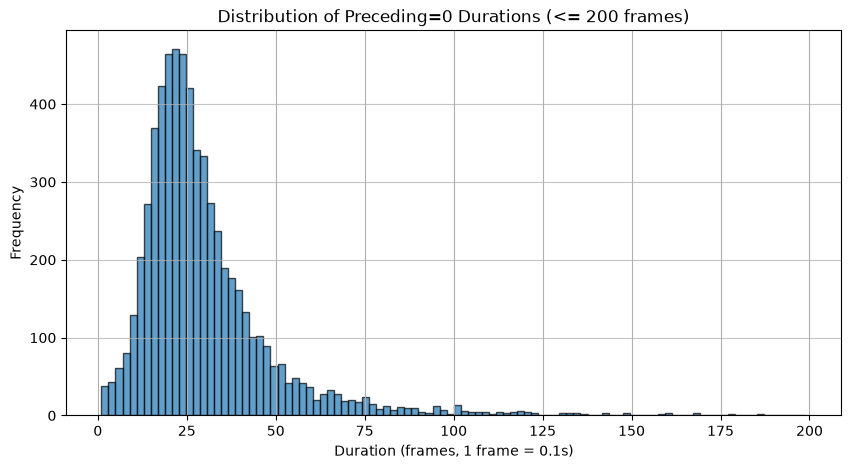

In [18]:
# データの読み込み
df = load_trajectory_data()

# Preceding=0の分布を確認
zero_durations = analyze_preceding_zero_duration(df)

In [13]:
def drop_short_preceding_zero(df, max_frames=5):
    """
    Preceding=0 が指定フレーム数（デフォルト5）以下しか続かないノイズ行を削除する関数
    """
    print(f"Preceding=0 が {max_frames} フレーム以下連続する行を削除中...")
    
    # データのソート（車両ごと、時間順）
    df = df.sort_values(['time_period', 'Vehicle_ID', 'Global_Time']).copy()
    
    # Precedingが0かどうかのフラグ
    is_zero = df['Preceding'] == 0
    
    # ブロックの境界を定義（車両ID、時間帯、または0/非0が切り替わったタイミング）
    boundary = (
        (df['Vehicle_ID'] != df['Vehicle_ID'].shift(1)) |
        (df['time_period'] != df['time_period'].shift(1)) |
        (is_zero != is_zero.shift(1))
    )
    
    # ブロックIDを付与
    df['block_id'] = boundary.cumsum()
    
    # Preceding=0 のブロックのみを抽出し、ブロックごとのサイズ（行数）を計算
    zero_block_sizes = df[is_zero].groupby('block_id').size()
    
    # 削除対象となるブロックIDを特定（サイズが max_frames 以下のもの）
    target_blocks = zero_block_sizes[zero_block_sizes <= max_frames].index
    
    # 削除対象行の条件: Preceding=0 であり、かつブロックIDが target_blocks に含まれる
    to_drop = is_zero & df['block_id'].isin(target_blocks)
    
    # 対象行を除外（~ は否定を意味します）
    df_filtered = df[~to_drop].copy()
    
    # 不要になった作業用列を削除
    df_filtered = df_filtered.drop(columns=['block_id'])
    
    # 結果の表示
    print(f"削除前の行数: {len(df):,}")
    print(f"削除後の行数: {len(df_filtered):,}")
    print(f"削除された行数: {to_drop.sum():,}")
    
    return df_filtered

In [14]:
# データの読み込み
df = load_trajectory_data()

# ★ 1〜5フレームの Preceding=0 行を削除
df = drop_short_preceding_zero(df, max_frames=5)

# ① ペアID付与（shift(1)に修正済みのもの）
df_with_pairs = give_pair_id(df)

(4566387, 19)
Preceding=0 が 5 フレーム以下連続する行を削除中...
削除前の行数: 4,566,387
削除後の行数: 4,566,060
削除された行数: 327


In [19]:
import pandas as pd

def verify_flickering(df, col_name='Preceding', max_frames=5):
    """
    指定した列で「A → B → A」となるフリッカリング現象を確認する関数
    """
    print(f"\n=== {col_name} のフリッカリング（A→B→A）確認 ===")
    df = df.sort_values(['time_period', 'Vehicle_ID', 'Global_Time']).copy()
    
    # 値が変化したタイミングでブロックIDを振る
    df['block_id'] = (df[col_name] != df[col_name].shift(1)).cumsum()
    
    # ブロック単位（連続して同じ値が続いている区間）のサマリーを作成
    blocks = df.groupby('block_id').agg(
        Vehicle_ID=('Vehicle_ID', 'first'),
        time_period=('time_period', 'first'),
        value=(col_name, 'first'),
        frame_count=('Global_Time', 'count')
    ).reset_index()
    
    # 同じ車両・時間帯の中で、前後のブロックの値を取得
    blocks['prev_value'] = blocks.groupby(['time_period', 'Vehicle_ID'])['value'].shift(1)
    blocks['next_value'] = blocks.groupby(['time_period', 'Vehicle_ID'])['value'].shift(-1)
    
    # フリッカリングの条件：
    # 1. 今のブロックの長さが max_frames 以下
    # 2. 前のブロックの値と次のブロックの値が完全に一致 (A -> B -> A)
    # 3. 前のブロックの値が存在する（データ端ではない）
    is_flicker = (
        (blocks['frame_count'] <= max_frames) & 
        (blocks['prev_value'] == blocks['next_value']) & 
        (blocks['prev_value'].notna())
    )
    
    flicker_blocks = blocks[is_flicker]
    
    print(f"検出されたフリッカリング(A→B→A)の総回数: {len(flicker_blocks):,} 回")
    
    if len(flicker_blocks) > 0:
        print("\nブレていたフレーム数（1〜5）ごとの発生回数:")
        print(flicker_blocks['frame_count'].value_counts().sort_index())
        
        print("\n具体的なフリッカリングの例（先頭5件）:")
        # わかりやすいように列名を変更して表示
        example = flicker_blocks[['Vehicle_ID', 'prev_value', 'value', 'next_value', 'frame_count']].head(5)
        example.columns = ['自車ID', '本来の値(A)', 'ノイズ値(B)', '戻った値(A)', 'ブレたフレーム数']
        print(example.to_string(index=False))

    return flicker_blocks

In [20]:
df = load_trajectory_data()

# Preceding（先行車）のフリッカリングを確認
verify_flickering(df, col_name='Preceding', max_frames=5)

# Lane_ID（車線）のフリッカリングを確認
verify_flickering(df, col_name='Lane_ID', max_frames=5)

(4566387, 19)

=== Preceding のフリッカリング（A→B→A）確認 ===
検出されたフリッカリング(A→B→A)の総回数: 434 回

ブレていたフレーム数（1〜5）ごとの発生回数:
frame_count
1     81
2     84
3    106
4     93
5     70
Name: count, dtype: int64

具体的なフリッカリングの例（先頭5件）:
 自車ID  本来の値(A)  ノイズ値(B)  戻った値(A)  ブレたフレーム数
  115   3333.0        0   3333.0         1
  136    115.0     3333    115.0         1
  168    164.0      162    164.0         4
  175    185.0      183    185.0         3
  268    257.0      264    257.0         5

=== Lane_ID のフリッカリング（A→B→A）確認 ===
検出されたフリッカリング(A→B→A)の総回数: 93 回

ブレていたフレーム数（1〜5）ごとの発生回数:
frame_count
1    17
2    21
3    21
4    18
5    16
Name: count, dtype: int64

具体的なフリッカリングの例（先頭5件）:
 自車ID  本来の値(A)  ノイズ値(B)  戻った値(A)  ブレたフレーム数
  268      3.0        4      3.0         5
  365      5.0        4      5.0         5
  365      4.0        5      4.0         2
  399      5.0        6      5.0         2
  447      3.0        2      3.0         3


,block_id,Vehicle_ID,time_period,value,frame_count,prev_value,next_value
226,227,268,1,4,5,3.0,3.0
309,310,365,1,4,5,5.0,5.0
310,311,365,1,5,2,4.0,4.0
356,357,399,1,6,2,5.0,5.0
393,394,447,1,2,3,3.0,3.0
...,...,...,...,...,...,...,...
7339,7340,1714,3,6,3,5.0,5.0
7547,7548,1913,3,6,5,5.0,5.0
7549,7550,1913,3,6,5,5.0,5.0
7662,7663,2027,3,5,3,6.0,6.0


In [21]:
import pandas as pd

# データの読み込み
# df = load_trajectory_data()

# 条件に合致するデータを抽出
df_target = df[(df['Vehicle_ID'] == 268) & (df['time_period'] == 1)]

# --------------------------------------------------
# パターン1: コンソール上で全ての行・列を表示する
# --------------------------------------------------
# 一時的にPandasの表示上限を無制限に設定
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print("=== Vehicle_ID: 268, time_period: 1 のデータ ===")
    # Preceding, Lane_ID, Frame_ID などの確認したい列だけ絞ると見やすいです
    print(df_target[['Frame_ID', 'Global_Time', 'Lane_ID', 'Preceding', 'v_Class', 'v_Vel']])

# --------------------------------------------------
# パターン2: CSVファイルとして出力して確認する（おすすめ）
# --------------------------------------------------
# カレントディレクトリにCSVを出力
csv_filename = "vehicle_268_time_1.csv"
df_target.to_csv(csv_filename, index=False)
print(f"\n{csv_filename} に全データを出力しました。")

=== Vehicle_ID: 268, time_period: 1 のデータ ===
        Frame_ID    Global_Time  Lane_ID  Preceding  v_Class  v_Vel
102262       967  1113433231600        3        267        3  13.79
102263       968  1113433231700        3        267        3  13.79
102264       969  1113433231800        3        267        3  13.79
102265       970  1113433231900        3        267        3  13.79
102266       971  1113433232000        3        267        3  13.79
102267       972  1113433232100        3        267        3  13.79
102268       973  1113433232200        3        267        3  13.25
102269       974  1113433232300        3        267        3  11.91
102270       975  1113433232400        3        267        3  11.00
102271       976  1113433232500        3        267        3  11.03
102272       977  1113433232600        3        267        3  11.58
102273       978  1113433232700        3        267        3  12.06
102274       979  1113433232800        3        267        3  12.13
102

In [24]:
import pandas as pd

def count_flickering_in_target_lanes(df, col_name='Preceding', max_frames=5, target_lanes=[2, 3, 4]):
    """
    対象レーン（デフォルト: 2, 3, 4）で発生しているフリッカリング（A→B→A）をカウントする関数
    """
    print(f"\n=== {col_name} のフリッカリング集計（対象レーン: {target_lanes}）===")
    df = df.sort_values(['time_period', 'Vehicle_ID', 'Global_Time']).copy()
    
    # ブロック（連続して同じ値が続く区間）ごとにIDを振る
    df['block_id'] = (df[col_name] != df[col_name].shift(1)).cumsum()
    
    # ブロック単位のサマリーを作成
    blocks = df.groupby('block_id').agg(
        Vehicle_ID=('Vehicle_ID', 'first'),
        time_period=('time_period', 'first'),
        value=(col_name, 'first'),
        frame_count=('Global_Time', 'count'),
        lane_id=('Lane_ID', 'first')  # ブロック開始時の車線IDを取得
    ).reset_index()
    
    # 同じ車両・時間帯の中で、前後ブロックの「値」と「車線」を取得
    blocks['prev_value'] = blocks.groupby(['time_period', 'Vehicle_ID'])['value'].shift(1)
    blocks['next_value'] = blocks.groupby(['time_period', 'Vehicle_ID'])['value'].shift(-1)
    blocks['prev_lane'] = blocks.groupby(['time_period', 'Vehicle_ID'])['lane_id'].shift(1)
    
    # フリッカリングの条件 (A -> B -> A)
    is_flicker = (
        (blocks['frame_count'] <= max_frames) & 
        (blocks['prev_value'] == blocks['next_value']) & 
        (blocks['prev_value'].notna())
    )
    
    flicker_blocks = blocks[is_flicker].copy()
    
    # 「ブレる直前の車線（本来走っていた車線）」が対象レーン(2,3,4)であるものに絞る
    target_flickers = flicker_blocks[flicker_blocks['prev_lane'].isin(target_lanes)]
    
    print(f"対象レーンでの {col_name} のフリッカリング総数: {len(target_flickers):,} 回")
    
    if len(target_flickers) > 0:
        print("\n--- レーン別の発生回数 ---")
        print(target_flickers['prev_lane'].value_counts().sort_index())
        
        print(f"\n--- ブレていたフレーム数（1〜{max_frames}）ごとの発生回数 ---")
        print(target_flickers['frame_count'].value_counts().sort_index())
        
    return target_flickers

# ==========================================
# 実行部分のサンプル
# ==========================================
# df = load_trajectory_data()

# 先行車(Preceding)のブレをカウント
preceding_flickers = count_flickering_in_target_lanes(df, col_name='Preceding', max_frames=5)

# 車線(Lane_ID)自体のブレをカウント
lane_flickers = count_flickering_in_target_lanes(df, col_name='Lane_ID', max_frames=5)


=== Preceding のフリッカリング集計（対象レーン: [2, 3, 4]）===
対象レーンでの Preceding のフリッカリング総数: 187 回

--- レーン別の発生回数 ---
prev_lane
2.0    77
3.0    46
4.0    64
Name: count, dtype: int64

--- ブレていたフレーム数（1〜5）ごとの発生回数 ---
frame_count
1    29
2    39
3    45
4    42
5    32
Name: count, dtype: int64

=== Lane_ID のフリッカリング集計（対象レーン: [2, 3, 4]）===
対象レーンでの Lane_ID のフリッカリング総数: 43 回

--- レーン別の発生回数 ---
prev_lane
2.0    13
3.0    16
4.0    14
Name: count, dtype: int64

--- ブレていたフレーム数（1〜5）ごとの発生回数 ---
frame_count
1     7
2    12
3     7
4     9
5     8
Name: count, dtype: int64


In [ ]:
def check_vclass_inconsistency(df):
    """
    ファイルごとの time_period と Vehicle_ID を組み合わせた完全識別子を作成し、
    同一車両内で v_Class (車種) がブレているケースを抽出する関数
    """
    print("=== 同一車両内で v_Class が変化しているケースの確認 ===")
    
    df_check = df.copy()
    
    # ★ 完全に識別可能であることを明示するため、一意な文字列ID（例: "1_268"）を作成
    df_check['unique_veh_id'] = df_check['time_period'].astype(str) + '_' + df_check['Vehicle_ID'].astype(str)
    
    # 完全一意識別子(unique_veh_id)をキーにして、存在する v_Class の種類を取得
    class_variations = df_check.groupby('unique_veh_id')['v_Class'].unique().reset_index()
    
    # v_Class の種類の数（リストの長さ）を計算
    class_variations['class_count'] = class_variations['v_Class'].apply(len)
    
    # 2種類以上の v_Class を持つ（途中で判定がブレた）一意車両を抽出
    inconsistent_vehicles = class_variations[class_variations['class_count'] > 1]
    
    print(f"v_Classが変化している完全識別車両の総数: {len(inconsistent_vehicles)} 件\n")
    
    if len(inconsistent_vehicles) > 0:
        print("詳細データ（先頭10件）:")
        print(inconsistent_vehicles[['unique_veh_id', 'v_Class', 'class_count']].head(10).to_string(index=False))
        
    return inconsistent_vehicles

In [26]:
check_vclass_inconsistency(df)

=== 同一車両内で v_Class が変化しているケースの確認 ===
v_Classが変化している完全識別車両の総数: 0 件



,unique_veh_id,v_Class,class_count


(4566387, 19)
=== 全Lane_IDブロックの長さ分布 (frame_count <= 20) ===
frame_count
1     23
2     26
3     26
4     29
5     21
6     20
7     16
8      9
9     11
10    12
11    12
12     8
13    11
14    10
15    13
16    15
17    14
18    12
19    12
20    20
Name: count, dtype: int64


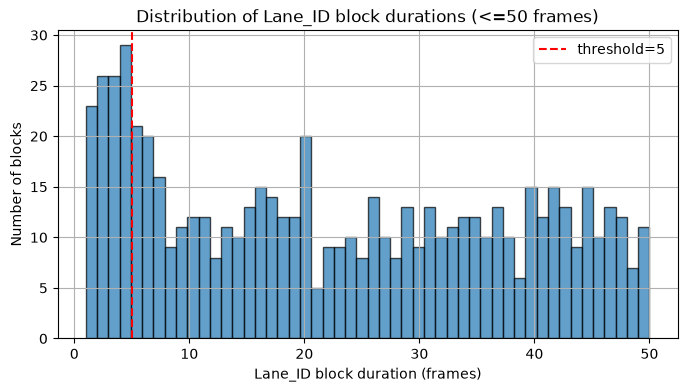


総ブロック数: 8,603
フリッカリング(A→B→A, 5フレーム以下)ブロック数: 95
影響を受ける行数: 281

=== フリッカリングの継続フレーム数内訳 ===
frame_count
1    17
2    21
3    22
4    19
5    16
Name: count, dtype: int64

=== 具体例（先頭5件） ===
 車両ID  時間帯  本来の車線(A)  ノイズ車線(B)  戻った車線(A)  継続フレーム数
  268    1       3.0         4       3.0        5
  365    1       5.0         4       5.0        5
  365    1       4.0         5       4.0        2
  399    1       5.0         6       5.0        2
  447    1       3.0         2       3.0        3


In [94]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_lane_flicker(df, threshold=5):
    """
    Lane_IDのブロック（同じ値が連続する区間）の長さ分布を確認し、
    さらに「短い区間(threshold以下)の前後が完全に同じLane_ID」という
    厳密なフリッカリングパターンがどれだけあるかを調べる。
    """
    df = df.sort_values(['time_period', 'Vehicle_ID', 'Global_Time']).copy()

    # 車両・時間帯・Lane_IDのいずれかが変わったら新しいブロック
    is_new_block = (
        (df['Vehicle_ID'] != df['Vehicle_ID'].shift()) |
        (df['time_period'] != df['time_period'].shift()) |
        (df['Lane_ID'] != df['Lane_ID'].shift())
    )
    df['_block_id'] = is_new_block.cumsum()

    blocks = df.groupby('_block_id').agg(
        Vehicle_ID=('Vehicle_ID', 'first'),
        time_period=('time_period', 'first'),
        value=('Lane_ID', 'first'),
        frame_count=('Lane_ID', 'size'),
    )
    blocks['prev_value'] = blocks.groupby(['Vehicle_ID', 'time_period'])['value'].shift(1)
    blocks['next_value'] = blocks.groupby(['Vehicle_ID', 'time_period'])['value'].shift(-1)

    # --- ① 全体のブロック長分布（ノイズかどうか問わず）---
    print("=== 全Lane_IDブロックの長さ分布 (frame_count <= 20) ===")
    print(blocks.loc[blocks['frame_count'] <= 20, 'frame_count'].value_counts().sort_index())

    plt.figure(figsize=(8, 4))
    blocks.loc[blocks['frame_count'] <= 50, 'frame_count'].hist(bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(threshold, color='red', linestyle='--', label=f'threshold={threshold}')
    plt.xlabel('Lane_ID block duration (frames)')
    plt.ylabel('Number of blocks')
    plt.title('Distribution of Lane_ID block durations (<=50 frames)')
    plt.legend()
    plt.show()

    # --- ② 厳密なフリッカリング判定 (A→B→A, B<=threshold) ---
    is_flicker = (
        (blocks['frame_count'] <= threshold)
        & (blocks['prev_value'] == blocks['next_value'])
        & blocks['prev_value'].notna()
    )
    flicker_blocks = blocks[is_flicker]

    print(f"\n総ブロック数: {len(blocks):,}")
    print(f"フリッカリング(A→B→A, {threshold}フレーム以下)ブロック数: {len(flicker_blocks):,}")
    print(f"影響を受ける行数: {flicker_blocks['frame_count'].sum():,}")

    if len(flicker_blocks) > 0:
        print("\n=== フリッカリングの継続フレーム数内訳 ===")
        print(flicker_blocks['frame_count'].value_counts().sort_index())

        print("\n=== 具体例（先頭5件） ===")
        example = flicker_blocks.reset_index()[
            ['Vehicle_ID', 'time_period', 'prev_value', 'value', 'next_value', 'frame_count']
        ].head(5)
        example.columns = ['車両ID', '時間帯', '本来の車線(A)', 'ノイズ車線(B)', '戻った車線(A)', '継続フレーム数']
        print(example.to_string(index=False))

    return flicker_blocks, blocks


# 実行（生データに対して。Precedingの補正とは独立の話なので、rawなdfでOK）
df = load_trajectory_data()
lane_flicker, lane_blocks = analyze_lane_flicker(df, threshold=5)

In [93]:
check_vclass_inconsistency(df)

=== 同一車両内で v_Class が変化しているケースの確認 ===
Lane_IDが変化している完全識別車両の総数: 1851 件

詳細データ（先頭10件）:
unique_veh_id   Lane_ID  class_count
        1_100    [4, 3]            2
       1_1005    [7, 6]            2
        1_102    [5, 4]            2
       1_1020 [7, 6, 5]            3
       1_1024    [7, 6]            2
        1_103    [6, 5]            2
       1_1031    [7, 6]            2
       1_1044    [4, 5]            2
       1_1049    [3, 4]            2
       1_1051    [3, 2]            2


,unique_veh_id,Lane_ID,class_count
1,1_100,"[4, 3]",2
6,1_1005,"[7, 6]",2
15,1_102,"[5, 4]",2
16,1_1020,"[7, 6, 5]",3
18,1_1024,"[7, 6]",2
...,...,...,...
5661,3_978,"[6, 5]",2
5664,3_982,"[4, 3]",2
5670,3_989,"[7, 6, 5]",3
5672,3_990,"[7, 6, 5, 4]",4
